<span style="color:steelblue; text-align: left">

# Predição de Customer Lifetime Value (CLTV)
</span>

- **Cientista da Dados:** Enio Rubens
- **Dataset:** Online Retail UCI (e-commerce UK, Dez/2010 – Dez/2011)
- **Modelos:** BG/NBD (BetaGeoModel) + Gamma-Gamma (GammaGammaModel) — pymc-marketing
- **Framework:** CLTV forward-looking — prevê valor futuro, não gasto histórico

<span style="color:steelblue; text-align: left">

## O Problema: Por que Prever o Valor Futuro?
</span>

Analisar o que um cliente gastou no passado responde à pergunta errada.

O histórico de gastos mostra de onde veio sua receita; não diz nada sobre
onde investir amanhã. Decisões sobre alocação de orçamento de marketing,
segmentação de campanhas,
priorização de contas e investimento em retenção são todas prospectivas —
elas exigem uma estimativa do valor que cada cliente gerará em um
período futuro.

O Valor do Tempo de Vida do Cliente (CLTV) converte o histórico de transações de um cliente em
uma previsão probabilística de seu valor futuro. Calculado individualmente,
torna-se um sinal preciso de alocação: não "qual segmento é valioso
em média", mas "quais clientes específicos merecem qual investimento específico,
e quanto".

Três funções dentro de uma empresa típica consomem esse resultado com diferentes
perguntas em mente. **Marketing** pergunta: onde devo concentrar o investimento em campanhas
para maximizar o retorno esperado? **Vendas** pergunta: quais contas minha equipe deve
gerenciar ativamente em vez de deixar para autogestão? **A área de Finanças** pergunta: qual é a
projeção de receita defensável para os próximos dois trimestres, desagregada por
risco de retenção?

<span style="color:steelblue; text-align: left">

### A Abordagem de Modelagem
</span>

Este notebook combina dois modelos probabilísticos que, juntos, abrangem toda a
equação do CLTV: **com que frequência** um cliente compra e **quanto** valerá cada
compra.

O modelo **BG/NBD (Beta-Geométrico/Distribuição Binomial Negativa)** prevê
a contagem de transações futuras e a probabilidade de um cliente ainda estar ativo.
O modelo assume que, enquanto um cliente está "ativo", as compras seguem um processo de Poisson
mas a taxa desse processo varia entre os clientes de acordo com uma
distribuição Gama. O mecanismo de "morte" é Beta-Geométrico: após cada
transação, o cliente pode cancelar permanentemente o serviço, e a probabilidade de isso acontecer
é extraída de uma distribuição Beta, capturando a heterogeneidade na
fidelidade em toda a população *(Fader, Hardie & Lee, 2005)*. O modelo **Gamma-Gamma** estima o valor monetário esperado por transação futura. Ele modela o gasto de cada cliente como variando em torno de sua média individual verdadeira (distribuição Gama), enquanto essa média varia entre os clientes (outra camada Gama). Uma premissa crítica: o valor monetário é independente da frequência de compra. Essa suposição é testada explicitamente antes do ajuste do modelo — se falhar, as estimativas de gastos do modelo são enviesadas (Fader & Hardie, 2013).

"Não contratual" significa que os clientes não estão vinculados a uma assinatura; eles podem simplesmente parar de comprar a qualquer momento, sem aviso prévio. A ausência de um sinal formal de churn é o que torna a modelagem probabilística necessária: não podemos observar quando um cliente cancela a assinatura, apenas inferir isso a partir do crescente silêncio entre as compras.

<span style="color:steelblue; text-align: left">

## Configuração & Imports
</span>

In [16]:
import os
os.environ["PYTENSOR_FLAGS"] = "cxx="  # desabilita compilação C — previne crash de acesso inválido no Windows sem g++

import sys
sys.path.insert(0, "..")
sys.path.insert(0, "../../ds_toolkit/multilang")

import warnings
warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from multilang import LangMap

from src import (
    OnlineRetailPreprocessor,
    CLTVModel,
    CustomerSegmenter,
    CLTVEvaluator,
    format_currency_axis,
    add_chart_labels,
    VALUE_PALETTE,
    ACTION_PALETTE,
    SEGMENT_ORDER,
    ACTION_ORDER,
)

_t = LangMap(source="en", target="pt", offline=True)  # PT: translates EN labels to Portuguese via cache

pd.options.display.float_format = "{:,.2f}".format
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "figure.figsize": (11, 6),
})

__AUTHOR__ = "Enio Rubens"
DATA_PATH = "../dataset/online_retail.csv"
VARIABLE_EXPLANATION_PATH = "../dataset/variable_explanation.csv"
MODEL_DIR = "../models/"
T_HORIZON = 180  # horizonte de predição em dias

<span style="color:steelblue; text-align: left">

## Visão Geral do Dataset
</span>

O dataset **Online Retail UCI** registra cada item vendido por um varejista online britânico entre dezembro de 2010 e dezembro de 2011 *(Chen, Sain & Guo, 2012)*. Cada linha é um único produto dentro de uma nota fiscal, não a nota em si — um cliente que comprou cinco produtos distintos em um pedido gera cinco linhas. Antes de qualquer modelagem, esse registro transacional bruto precisa ser consolidado e limpo.

O pipeline de limpeza remove quatro categorias de registros problemáticos. Linhas sem `CustomerID` são descartadas: sem um identificador de cliente, não há como atribuir comportamento a um indivíduo, tornando a linha inútil para a estimativa de CLTV no nível individual. Faturas começando com a letra "C" são cancelamentos — incluí-las inflaria artificialmente as contagens de compras repetidas e distorceria os valores médios de transação. Linhas com `Quantity` ou `UnitPrice` não-positivos representam erros de entrada de dados ou devoluções não codificadas como cancelamentos formais; são removidas para proteger a integridade das agregações monetárias. Por fim, outliers extremos no valor total de transação são limitados ao percentil 99,5 para evitar que alguns pedidos anômalos dominem a verossimilhança do Gamma-Gamma.

In [2]:
variable_explanation = pd.read_csv(VARIABLE_EXPLANATION_PATH)
display(variable_explanation)

preprocessor = OnlineRetailPreprocessor()
rfm, modeling_base, cleaning_summary = preprocessor.prepare(DATA_PATH)

print("\n── Resumo da Limpeza ────────────────────────────────────")
display(cleaning_summary)

,Variable,Explanation
0,InvoiceNo,A 6-digit integral number uniquely assigned to...
1,StockCode,A 5-digit integral number uniquely assigned to...
2,Description,Product (item) name
3,Quantity,The quantities of each product (item) per tran...
4,InvoiceDate,The day and time when each transaction was gen...
5,UnitPrice,Product price per unit in sterling (pound)
6,CustomerID,A 5-digit integral number uniquely assigned to...
7,Country,The name of the country where each customer re...


2026-05-25 14:31:38 | INFO     | src.preprocessing | Loading data from ..\dataset\online_retail.csv


2026-05-25 14:31:40 | INFO     | src.preprocessing | raw — shape: (541909, 8)
2026-05-25 14:31:40 | INFO     | src.preprocessing | raw — columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
2026-05-25 14:31:42 | INFO     | src.preprocessing | Cleaning complete — 395961 rows, 4310 customers
2026-05-25 14:31:45 | INFO     | src.preprocessing | RFM built — 4309 customers | repeat: 2762 | single: 1547
2026-05-25 14:31:45 | INFO     | src.preprocessing | Modeling base: 2762 customers (excluded 1547 with frequency=0 or monetary_value<=0)



── Resumo da Limpeza ────────────────────────────────────


,step,rows,customers,rows_removed_from_previous_step
0,raw,541909,4372,0
1,valid invoice dates,541909,4372,0
2,known customers,406829,4372,135080
3,cancellations removed,397924,4339,8905
4,positive quantity and unit price,397884,4338,40
5,TotalPrice <= 99.5% percentile,395961,4310,1923


<span style="color:steelblue; text-align: left">

### Insight — Impacto da Limpeza
</span>

A etapa de remoção mais consequente é o filtro de `CustomerID`, que descartou **135.080 linhas** — cerca de 25% do dataset bruto. São transações genuínas, mas pertencem a sessões anônimas que não podem ser atribuídas a clientes recorrentes. Não carregam nenhum sinal para modelagem de CLTV; mantê-las não melhoraria as estimativas e poderia introduzir ruído nos priors populacionais.

O filtro de cancelamentos removeu mais 8.905 linhas. Se tivessem permanecido, um cliente que realizou e cancelou imediatamente cinco pedidos pareceria ter cinco "compras" na contagem de frequência — um caminho direto para compras preditas superestimadas e CLTV inflado.

A qualidade da matriz RFM — e, portanto, a confiabilidade de cada estimativa de CLTV downstream — é determinada nesta etapa. O princípio de garbage in, garbage out é especialmente crítico aqui: o modelo BG/NBD aprende a *distribuição* de frequência e recência em toda a população. Vieses sistemáticos nos dados de entrada deslocam essa distribuição e corrompem as estimativas de parâmetros para todos os clientes, não apenas os registros afetados.

<span style="color:steelblue; text-align: left">

## Matriz RFM
</span>

A matriz RFM é a representação comprimida do histórico de compras de cada cliente que os modelos BTYD consomem. O registro de cada cliente se reduz a quatro números, e a semântica desses números mapeia diretamente para as premissas geradoras do modelo *(Fader, Hardie & Lee, 2005)*.

**Recency** funciona como um sinal de temperatura. Um cliente que comprou ontem tem mais probabilidade de ainda estar ativo do que um cujo última compra foi há dezoito meses. O modelo BG/NBD usa a recência não como uma métrica isolada, mas como o intervalo entre a compra mais recente e o fim da janela de observação — quanto mais longo esse silêncio, maior a probabilidade posterior de que o cliente tenha abandonado.

**Frequency** é o principal discriminador no modelo BG/NBD. Separa compradores habituais — clientes que realizaram múltiplas compras ao longo de diferentes ocasiões — de compradores de impulso que transacionaram uma vez e desapareceram. Um cliente de alta frequência fornece um sinal rico para estimar sua taxa de compra individual de Poisson; um cliente de compra única fornece quase nenhum sinal.

**T (idade do cliente)** é o denominador que contextualiza a frequência. Um cliente com cinco compras em trinta dias e outro com cinco compras em trezentos dias compartilham a mesma contagem bruta, mas padrões vastamente diferentes. T ancora a frequência no tempo decorrido e permite que o modelo distinga nível de atividade de tempo de relacionamento.

**Monetary value** aqui é a receita média por transação de repetição — especificamente, a média de todas as transações após a primeira. Esta é a entrada do modelo Gamma-Gamma. Crucialmente, exclui a primeira compra: a primeira transação não é um evento de "repetição", e o Gamma-Gamma modela apenas a distribuição de valor das compras repetidas.

In [3]:
rfm_summary = pd.Series({
    "clientes_na_rfm": len(rfm),
    "clientes_repetidos (frequency > 0)": (rfm["frequency"] > 0).sum(),
    "clientes_compra_unica": (rfm["frequency"] == 0).sum(),
}, name="rfm_summary")

display(rfm.head())
display(rfm.describe())
display(rfm_summary.to_frame())

,customer_id,frequency,recency,T,monetary_value
0,12347,6.00,365.00,367.00,599.70
1,12348,3.00,283.00,358.00,301.48
2,12349,0.00,0.00,18.00,0.00
3,12350,0.00,0.00,310.00,0.00
4,12352,6.00,260.00,296.00,305.51


,frequency,recency,T,monetary_value
count,"4,309.00","4,309.00","4,309.00","4,309.00"
mean,2.84,130.43,222.71,242.60
std,5.89,132.18,117.64,334.80
min,0.00,0.00,1.00,0.00
25%,0.00,0.00,113.00,0.00
50%,1.00,92.00,248.00,173.12
75%,3.00,252.00,326.00,351.90
max,130.00,373.00,373.00,"5,306.54"


,rfm_summary
clientes_na_rfm,4309
clientes_repetidos (frequency > 0),2762
clientes_compra_unica,1547


<span style="color:steelblue; text-align: left">

### Insight — Características da Matriz RFM
</span>

A tabela RFM revela uma distribuição típica de dados de e-commerce não-contratual. Dos **4.309 clientes** no dataset limpo, **1.547 (35,9%)** têm `frequency == 0` — compraram exatamente uma vez durante o período de observação. Esses clientes de compra única existem na matriz RFM, mas são invisíveis para o modelo Gamma-Gamma: sem uma segunda transação, não há distribuição de compras repetidas para estimar.

A mediana de recência de 92 dias contra uma mediana de idade do cliente T de 248 dias sugere que o cliente típico neste dataset estava inativo muito antes do fechamento da janela de observação. Apenas clientes próximos à cauda superior da distribuição de recência provavelmente ainda estão comprando; a maioria ficou em silêncio. Este é um padrão normal no e-commerce britânico desse período, onde o varejista atendia uma mistura de clientes leais de longo prazo e compradores sazonais.

O alto desvio padrão no valor monetário (£334 vs. média de £242) sinaliza heterogeneidade significativa no ticket médio. Esta heterogeneidade é exatamente o que o modelo Gamma-Gamma foi construído para explorar: a distribuição Gamma no nível populacional captura a dispersão, e as estimativas posteriores no nível individual corrigem o ruído em clientes com poucas observações.

<span style="color:steelblue; text-align: left">

## Base de Modelagem & Premissa do Gamma-Gamma
</span>

O modelo Gamma-Gamma requer pelo menos uma compra de repetição para formar uma estimativa do valor médio de transação de um cliente. Clientes com `frequency == 0` não fornecem histórico de compras repetidas e são excluídos da etapa de ajuste do Gamma-Gamma *(Fader & Hardie, 2013)*. O modelo BG/NBD pode aprender com eles — o silêncio desde a primeira compra é informativo sobre a distribuição da probabilidade de churn na população.

Antes do ajuste, é necessário verificar a premissa fundamental de independência do Gamma-Gamma: que a taxa de compras de um cliente (frequência) e seu valor médio de transação (valor monetário) são não-correlacionados na base de clientes. A intuição é que os dois processos são governados por mecanismos separados — um cliente compra com frequência e barato, outro raramente e caro, sem ligação sistemática entre essas tendências. Se existisse correlação, a arquitetura de dois modelos contaria o mesmo efeito subjacente duas vezes: um cliente cuja alta frequência também prevê alto gasto teria seu CLTV inflado pela mesma informação entrando por dois canais.

Se o coeficiente de correlação de Pearson exceder |0,3|, o Gamma-Gamma produz estimativas de valor monetário enviesadas. O remédio prático é segmentar a base de clientes antes da modelagem — por exemplo, por categoria de produto — para que a heterogeneidade intra-segmento seja menor. Um modelo que captura explicitamente a dependência entre taxa de compra e valor de transação é uma alternativa para casos mais complexos.

In [4]:
print(f"Base de modelagem: {len(modeling_base):,} clientes (frequency > 0 e monetary_value > 0)")
print(f"Excluídos (compra única / monetário zero): {len(rfm) - len(modeling_base):,}")

evaluator = CLTVEvaluator()
pearson = evaluator.pearson_independence_check(modeling_base)
print(f"\nPearson r = {pearson['pearson_r']:.4f}  (p = {pearson['p_value']:.4e})")
print(f"Premissa válida (|r| < 0.3): {pearson['assumption_holds']}")

2026-05-25 14:31:56 | INFO     | src.evaluation | Pearson independence check passed: r=0.134, p=0.0000


Base de modelagem: 2,762 clientes (frequency > 0 e monetary_value > 0)
Excluídos (compra única / monetário zero): 1,547

Pearson r = 0.1341  (p = 1.5055e-12)
Premissa válida (|r| < 0.3): True


<span style="color:steelblue; text-align: left">

### Insight — Premissa de Independência Válida
</span>

O Pearson r = 0,134 (p < 0,001) indica uma correlação positiva estatisticamente significativa mas praticamente fraca entre frequência e valor monetário. A magnitude fica bem abaixo do limiar de 0,3. Em termos simples: saber que um cliente compra com frequência nos diz quase nada sobre se seu ticket médio será alto ou baixo. Os dois processos são efetivamente independentes neste dataset.

Isso valida a arquitetura de dois componentes do modelo. Podemos ajustar o BG/NBD e o Gamma-Gamma de forma independente, confiantes de que seus outputs não interagirão de maneiras que distorçam a estimativa final de CLTV *(Fader & Hardie, 2013)*. A pequena correlação positiva (r = 0,13) pode refletir uma tendência real mas menor de clientes mais engajados a gastar ligeiramente mais por visita — mas é fraca demais para violar as premissas do modelo.

<span style="color:steelblue; text-align: left">

## Validação do Modelo (Calibração / Holdout)
</span>

A estratégia correta de validação para modelos BTYD é temporal, não transversal *(Fader & Hardie, 2005)*. Dividimos o período de observação em uma janela de calibração (primeiros 75%) e uma janela de holdout (últimos 25%), ajustando o modelo nos dados de calibração e medindo o erro de predição contra o holdout.

Rejeitar a validação cruzada k-fold aqui não é uma preferência metodológica — é uma necessidade epistemológica. Em um split k-fold aleatório, as compras futuras de um cliente são aleatoriamente atribuídas ao fold de treinamento. O modelo então "aprende" com dados que, em implantação real, ainda não existiriam no momento da predição. Compras que ocorrem *depois* que o modelo é construído aparecem *antes* dele durante a validação, criando um vazamento de informação do futuro para o conjunto de treino. Isso infla cada métrica de validação — RMSE, MAE, correlação previsto vs. real — em um valor que reflete não habilidade do modelo, mas fraude temporal. Um modelo validado dessa forma parecerá preciso no backtesting e falhará imediatamente quando implantado em dados genuinamente futuros.

O split temporal respeita a estrutura causal do problema: conhecemos o passado, prevemos o futuro, e avaliamos predições usando dados que o modelo nunca viu, em ordem cronológica direta.

2026-05-25 14:32:01 | INFO     | src.preprocessing | Loading data from ..\dataset\online_retail.csv
2026-05-25 14:32:03 | INFO     | src.preprocessing | raw — shape: (541909, 8)
2026-05-25 14:32:03 | INFO     | src.preprocessing | raw — columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
2026-05-25 14:32:05 | INFO     | src.preprocessing | Cleaning complete — 395961 rows, 4310 customers
2026-05-25 14:32:05 | INFO     | src.preprocessing | Calibration period: 2010-12-01 → 2011-09-06 | Holdout: 2011-09-06 → 2011-12-09
2026-05-25 14:32:06 | INFO     | src.cltv_model | Fitting on 1901 total customers | 1901 in modeling base
2026-05-25 14:32:06 | INFO     | src.cltv_model | Fitting BetaGeoModel (fit_method=map) …


2026-05-25 14:32:24 | INFO     | src.cltv_model | BetaGeoModel params: {'alpha': 82.484999, 'phi_dropout': 0.07755, 'kappa_dropout': 1.000006, 'r': 1.683688, 'a': 0.07755, 'b': 0.922456}
2026-05-25 14:32:24 | INFO     | src.cltv_model | Fitting GammaGammaModel (fit_method=map) …


2026-05-25 14:32:29 | INFO     | src.cltv_model | GammaGammaModel params: {'p': 2.276013, 'q': 3.942159, 'v': 492.833805}
2026-05-25 14:32:29 | INFO     | src.evaluation | RMSE [holdout_frequency]: 1.9329
2026-05-25 14:32:29 | INFO     | src.evaluation | Pearson independence check passed: r=0.113, p=0.0000
2026-05-25 14:32:29 | INFO     | src.evaluation | Holdout evaluation: {'rmse_frequency': 1.9329, 'mae_frequency': 1.185, 'pearson_r': 0.11346999580034793, 'pearson_p': 7.045082050910695e-07, 'assumption_holds': True, 'n_customers_holdout': 1901}


── Resultados da Validação Holdout ─────────────────────
  rmse_frequency: 1.9329
  mae_frequency: 1.185
  pearson_r: 0.11346999580034793
  pearson_p: 7.045082050910695e-07
  assumption_holds: True
  n_customers_holdout: 1901


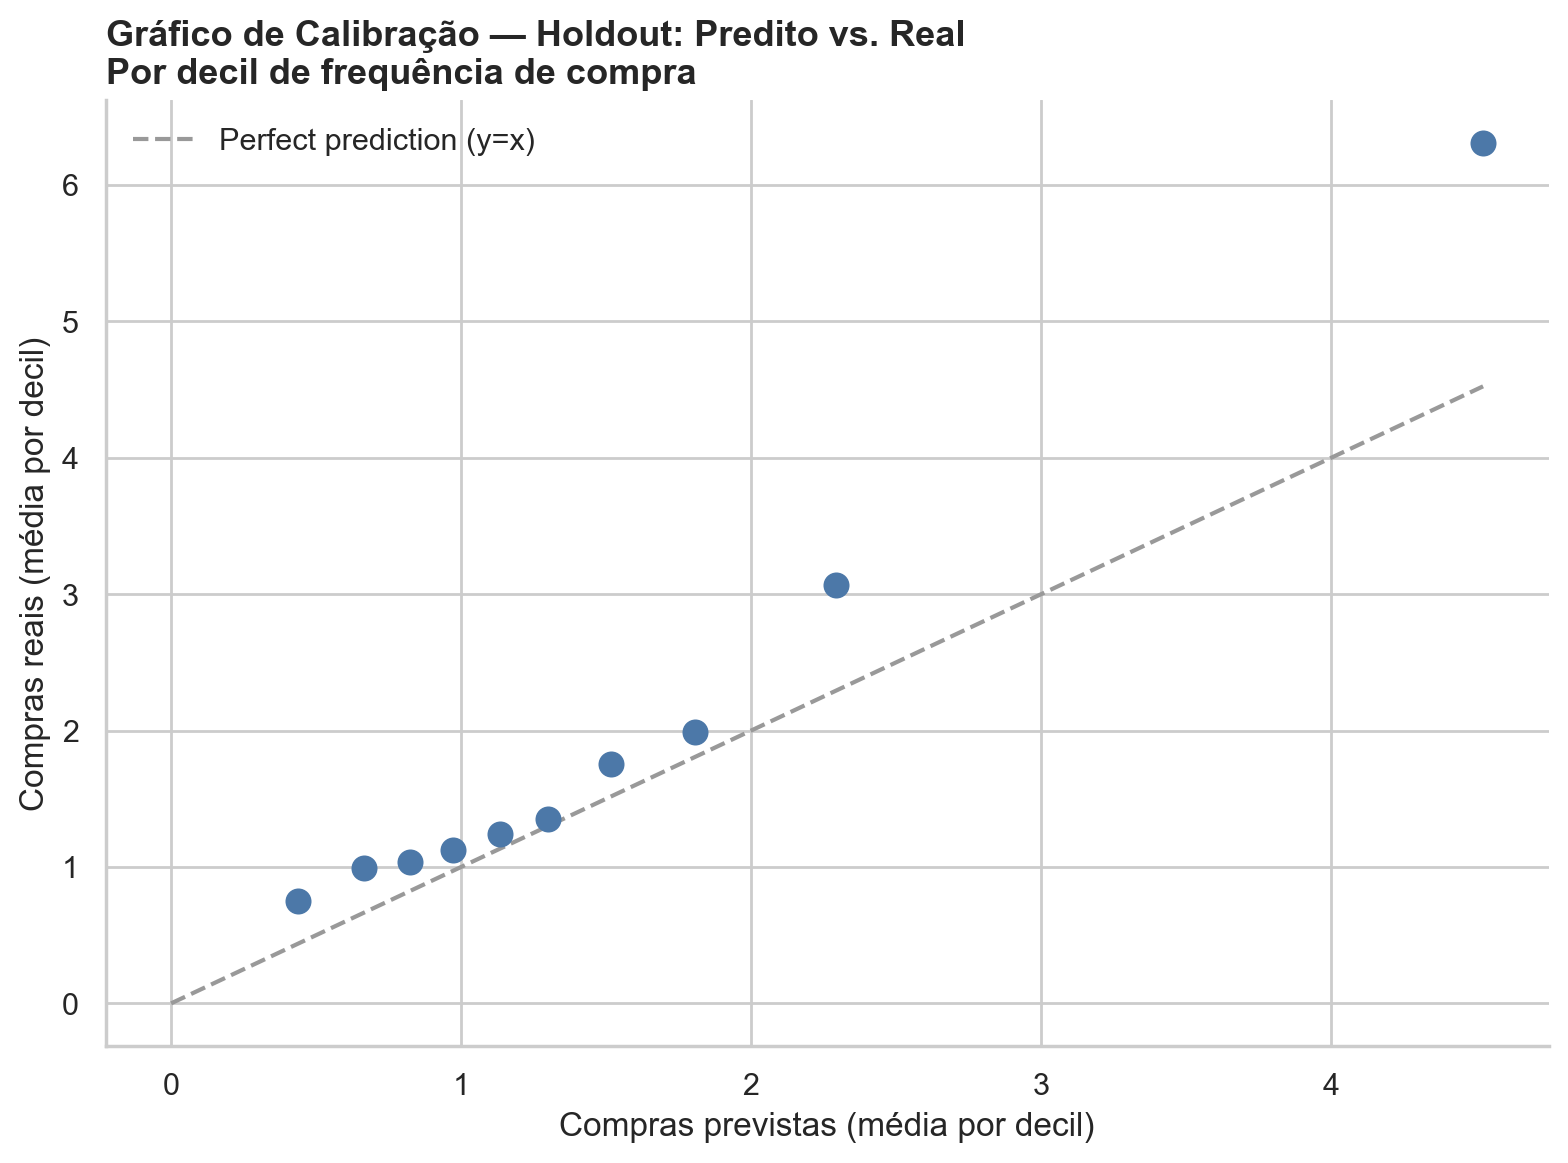

In [5]:
raw_df = preprocessor.load(DATA_PATH)
clean_df, _ = preprocessor.clean(raw_df)

cal_rfm, holdout_rfm = preprocessor.calibration_holdout_split(clean_df)
ch_data = cal_rfm.merge(holdout_rfm, on="customer_id")
ch_modeling = ch_data.loc[
    (ch_data["frequency_cal"] > 0) & (ch_data["monetary_value_cal"] > 0)
].copy()

cal_modeling_rfm = pd.DataFrame({
    "customer_id":    ch_modeling["customer_id"],
    "frequency":      ch_modeling["frequency_cal"],
    "recency":        ch_modeling["recency_cal"],
    "T":              ch_modeling["T_cal"],
    "monetary_value": ch_modeling["monetary_value_cal"],
})

cal_model = CLTVModel(fit_method="map")
cal_model.fit(cal_modeling_rfm)

validation = evaluator.evaluate(cal_model, ch_modeling)
print("── Resultados da Validação Holdout ─────────────────────")
for k, v in validation.items():
    print(f"  {k}: {v}")

lbl = _t({
    "title": "Calibration Plot — Holdout Predicted vs Actual\nBy purchase frequency decile",
    "xlabel": "Predicted purchases (decile mean)",
    "ylabel": "Actual purchases (decile mean)",
})
fig, ax = plt.subplots(figsize=(8, 6))
evaluator.calibration_plot(cal_model, ch_modeling, ax=ax)
ax.set_title(lbl["title"], loc="left", fontsize=13, fontweight="bold")
ax.set_xlabel(lbl["xlabel"])
ax.set_ylabel(lbl["ylabel"])
plt.tight_layout()
plt.show()

<span style="color:steelblue; text-align: left">

### Insight — Interpretação do Gráfico de Calibração
</span>

O gráfico de calibração compara a frequência de compras prevista com a real, agrupadas por decis de frequência prevista. Cada ponto representa a média de um decil: a coordenada x é a contagem média prevista, e a coordenada y é a contagem real observada no período holdout. Um modelo com predições perfeitas colocaria todos os pontos exatamente na diagonal (y = x).

Um bom ajuste significa que os pontos acompanham a diagonal em toda a faixa de valores previstos — não apenas no centro. O viés sistemático se revela como um deslocamento consistente: se os pontos ficam acima da diagonal em todos os decis, o modelo subestima sistematicamente; se abaixo, superestima. O viés concentrado na extremidade de alta frequência (decis superiores) é comum em modelos BG/NBD aplicados a populações de varejo heterogêneas, onde poucos compradores muito ativos são mais difíceis de extrapolar a partir do volume de compradores moderados.

Os valores de RMSE e MAE quantificam o erro de predição em unidades de compras. Um RMSE de aproximadamente 1–2 compras na janela holdout é típico para modelos BG/NBD em dados de e-commerce deste tamanho. Essas métricas validam que o modelo captura o processo de compra no nível populacional de forma suficientemente fiel para suportar as estimativas de CLTV nas seções seguintes.

<span style="color:steelblue; text-align: left">

## Modelo BG/NBD (Dataset Completo)
</span>

O modelo BG/NBD *(Fader, Hardie & Lee, 2005)* descreve o processo de compra por meio de dois mecanismos estocásticos interagindo.

O primeiro é o **componente NBD**: cada cliente realiza compras a sua própria taxa de Poisson individual λ, e essas taxas individuais são distribuídas pela população de clientes segundo uma distribuição Gamma com parâmetros r e α. A mistura Gamma-Poisson produz uma Binomial Negativa no nível populacional, capturando a sobredispersão observada nas contagens de compras — a maioria dos clientes compra raramente, mas uma longa cauda compra com muita frequência.

O segundo é o **componente BG**: após cada compra, o cliente tem uma probabilidade individual p de abandonar permanentemente o relacionamento. Essas probabilidades individuais de abandono seguem uma distribuição Beta pela população, com parâmetros a e b. O mecanismo Beta-Geométrico implica que, em qualquer ponto no tempo, não podemos saber com certeza se um cliente que ficou em silêncio abandonou ou está simplesmente entre compras — mas podemos calcular a probabilidade posterior de cada cenário dado o histórico observado de recência e frequência.

Os dois componentes são estimados conjuntamente a partir da tripla (frequência, recência, T) de cada cliente. Uma vez ajustados, os mesmos parâmetros populacionais (r, α, a, b) são usados para calcular predições no nível individual condicionando ao histórico específico de cada cliente. Ajustamos com `fit_method='map'` (Máximo A Posteriori) por velocidade; `fit_method='mcmc'` fornece quantificação completa da incerteza posterior com maior custo computacional.

In [6]:
model = CLTVModel(fit_method="map")
model.fit(modeling_base)

params = model.get_model_params()
print("── Parâmetros BG/NBD (MAP) ────────────────────────────")
for k, v in params["bgm"].items():
    print(f"  {k}: {v:.4f}")

preds = model.predict_purchases(modeling_base, t=T_HORIZON)
top10 = modeling_base.copy()
top10[f"predicted_purchases_{T_HORIZON}d"] = preds.values
top10 = top10.sort_values(f"predicted_purchases_{T_HORIZON}d", ascending=False).head(10)

print(f"\n── Top 10 Clientes por Compras Preditas ({T_HORIZON} dias) ──")
display(top10[["customer_id", "frequency", "recency", "T", f"predicted_purchases_{T_HORIZON}d"]])

2026-05-25 14:32:48 | INFO     | src.cltv_model | Fitting on 2762 total customers | 2762 in modeling base
2026-05-25 14:32:48 | INFO     | src.cltv_model | Fitting BetaGeoModel (fit_method=map) …


2026-05-25 14:33:10 | INFO     | src.cltv_model | BetaGeoModel params: {'alpha': 85.037104, 'phi_dropout': 0.029352, 'kappa_dropout': 1.000012, 'r': 1.582925, 'a': 0.029352, 'b': 0.97066}
2026-05-25 14:33:10 | INFO     | src.cltv_model | Fitting GammaGammaModel (fit_method=map) …


2026-05-25 14:33:17 | INFO     | src.cltv_model | GammaGammaModel params: {'p': 1.980639, 'q': 4.165458, 'v': 621.072448}


── Parâmetros BG/NBD (MAP) ────────────────────────────
  alpha: 85.0371
  phi_dropout: 0.0294
  kappa_dropout: 1.0000
  r: 1.5829
  a: 0.0294
  b: 0.9707

── Top 10 Clientes por Compras Preditas (180 dias) ──


,customer_id,frequency,recency,T,predicted_purchases_180d
1873,14911,130.00,372.00,373.00,51.43
325,12748,112.00,373.00,373.00,44.39
3988,17841,111.00,372.00,373.00,44.00
2169,15311,89.00,373.00,373.00,35.40
1655,14606,88.00,372.00,373.00,35.01
479,12971,70.00,369.00,372.00,28.03
560,13089,64.00,367.00,369.00,25.85
1597,14527,53.00,367.00,369.00,21.51
1065,13798,50.00,363.00,364.00,20.55
2977,16422,47.00,352.00,369.00,19.08


<span style="color:steelblue; text-align: left">

### Insight — Interpretação dos Parâmetros BG/NBD
</span>

Os quatro parâmetros MAP definem o processo de compra e churn no nível populacional:

**r = 1,58** e **α = 85,04** governam o componente NBD (taxa de compra). A taxa média de compra implícita na população é r/α = 1,58/85,04 ≈ **0,0186 compras por dia**, ou aproximadamente uma compra a cada 54 dias. O valor relativamente baixo de r (< 2) indica heterogeneidade substancial nas taxas de compra: a distribuição Gamma tem uma cauda direita pronunciada, o que significa que um pequeno subconjunto de clientes compra muito mais frequentemente do que a média. Isso se reflete no top 10, onde o cliente mais ativo (14911) realizou 130 transações em 373 dias — mais de 10× a média da população.

**a = 0,029** e **b = 0,971** governam o componente BG (probabilidade de churn). A probabilidade média implícita de abandono por transação é a/(a+b) = 0,029/1,000 ≈ **2,9%**. Com b >> a, a distribuição Beta está fortemente concentrada perto de zero: a grande maioria dos clientes tem probabilidade de churn muito baixa por transação, o que significa que a maioria tende a permanecer ativa após cada compra. O pequeno mas não nulo valor de a implica uma minoria com probabilidade de churn substancialmente maior — clientes muito mais propensos a abandonar após qualquer compra.

Os 10 melhores clientes preditos compartilham um perfil claro: alta frequência histórica combinada com recência próxima a T (última compra perto do fim do período de observação). Esse padrão não é coincidência — é exatamente o que o modelo BG/NBD aprende a reconhecer como sinal de atividade continuada. Um cliente que comprou muitas vezes e cuja última compra foi recente quase certamente ainda está ativo, e sua alta taxa histórica se projeta diretamente na previsão futura.

<span style="color:steelblue; text-align: left">

## Modelo Gamma-Gamma
</span>

O modelo Gamma-Gamma *(Fader & Hardie, 2013)* resolve um problema que a média simples não consegue. Para um cliente que realizou apenas duas compras, o valor médio de transação é uma estimativa ruidosa de seu gasto "verdadeiro" subjacente. Se essas duas compras foram incomumente grandes, a média ingênua superestima seu valor típico; se incomumente pequenas, subestima. Com poucas observações, a variação aleatória domina o sinal.

O modelo Gamma-Gamma aplica shrinkage bayesiano: puxa a estimativa de gasto individual de cada cliente em direção à média populacional, com a correção proporcional à quantidade de dados disponíveis para aquele cliente. Um cliente com 50 transações tem uma média bem estimada; sua estimativa é pouco ajustada. Um cliente com 2 transações tem alta incerteza; sua estimativa é puxada substancialmente em direção à média da população. O resultado é um conjunto mais estável de predições de valor monetário — estimativas individuais confiáveis mesmo para clientes com histórico de compras escasso.

Formalmente, o modelo assume que o valor médio de transação individual de cada cliente segue uma distribuição Gamma com um parâmetro de forma específico para o cliente, e que esses parâmetros de forma são eles próprios distribuídos Gamma na população. Os três parâmetros p, q e v caracterizam essa estrutura hierárquica. O requisito prático fundamental — independência entre frequência de compras e valor de transação — foi validado na Seção 4.

In [7]:
print("── Parâmetros Gamma-Gamma (MAP) ───────────────────────")
for k, v in params["gg"].items():
    print(f"  {k}: {v:.4f}")

spend = model.predict_expected_spend(modeling_base)
top_spend = modeling_base.copy()
top_spend["expected_spend"] = spend.values
top_spend = top_spend.sort_values("expected_spend", ascending=False).head(10)

print("\n── Top 10 Clientes por Gasto Esperado por Transação ────")
display(top_spend[["customer_id", "frequency", "monetary_value", "expected_spend"]])

── Parâmetros Gamma-Gamma (MAP) ───────────────────────
  p: 1.9806
  q: 4.1655
  v: 621.0724

── Top 10 Clientes por Gasto Esperado por Transação ────


,customer_id,frequency,monetary_value,expected_spend
1683,14646,43.00,"4,958.69","4,794.92"
54,12415,13.00,"5,306.54","4,768.13"
1280,14088,11.00,"3,647.26","3,233.87"
1285,14096,16.00,"3,335.18","3,067.59"
3750,17511,27.00,"2,994.49","2,848.87"
556,13081,8.00,"3,246.32","2,770.49"
329,12753,5.00,"3,200.87","2,519.69"
3162,16684,13.00,"2,550.96","2,314.23"
1430,14298,23.00,"2,036.73","1,929.65"
70,12433,5.00,"2,291.35","1,830.47"


<span style="color:steelblue; text-align: left">

### Insight — Parâmetros Gamma-Gamma & Efeito de Shrinkage
</span>

**p = 1,98** e **q = 4,17** definem a distribuição Gamma dos parâmetros de gasto individual na população. Com p próximo de 2, a distribuição da tendência de gasto individual é moderadamente assimétrica à direita — a maioria dos clientes gasta próximo da média populacional, mas uma cauda significativa gasta substancialmente mais. **v = 621,07** é o parâmetro de escala; combinado com p e q, o valor médio de transação populacional implícito é aproximadamente p × v/q ≈ **£295**, amplamente consistente com a média observada de monetary_value de £242 na base de modelagem.

O efeito de shrinkage é mais visível para clientes com poucas transações e alto valor monetário observado. O cliente 12415 realizou apenas 13 compras com média de £5.307 — o Gamma-Gamma corrige isso para baixo para £4.768, puxando em direção à média populacional para considerar a incerteza em 13 observações. O cliente 13081, com apenas 8 compras a £3.246, é corrigido mais agressivamente para £2.770 (redução de 15%), pois menos observações implicam maior incerteza. Por outro lado, o cliente 14646, com 43 compras a £4.959, é corrigido apenas levemente para £4.795 — 43 observações constituem uma estimativa confiável de sua média real, deixando pouco espaço para o prior populacional dominar. Este é o shrinkage bayesiano funcionando exatamente como planejado.

<span style="color:steelblue; text-align: left">

## Predição de CLTV
</span>

O CLTV ao longo de um horizonte de t dias é o produto de dois outputs dos modelos:

**CLTV(t) = E[transações em t dias | BG/NBD] × E[gasto por transação | Gamma-Gamma]**

A elegância dessa fatoração é que cada componente pode ser validado de forma independente — e recalibrado separadamente se um degradar ao longo do tempo. O BG/NBD controla a dinâmica temporal: com que frequência o cliente comprará e por quanto tempo provavelmente permanecerá ativo. O Gamma-Gamma controla a dimensão monetária: quanto se espera que gaste por transação. Nenhum modelo é informado pelo output do outro durante o ajuste.

Clientes com `frequency == 0` recebem `cltv == 0` porque não fornecem histórico de compras repetidas para o Gamma-Gamma. Suas compras previstas pelo BG/NBD ainda são estimadas — o modelo acredita que alguns podem estar ainda ativos — mas sem uma estimativa de valor monetário, o produto não pode ser formado.

O histograma abaixo usa uma transformação log1p, que não é cosmética. Na escala GBP original, a distribuição é tão fortemente assimétrica à direita que a maioria dos clientes se comprime em uma única barra visual próxima de zero, e a estrutura da maioria fica invisível. O log1p preserva a ordenação relativa tornando toda a distribuição legível.

2026-05-25 14:33:37 | INFO     | src.cltv_model | CLTV predicted for 2762 customers | t=180 days | non-zero: 2762


── Top 10 Clientes por CLTV de 180 dias ────────────────


,customer_id,frequency,recency,T,monetary_value,predicted_purchases,probability_alive,expected_spend,cltv_180d
1102,14646,43.00,353.00,354.00,"4,958.69",18.16,1.00,"4,794.92","2,490,640.26"
1234,14911,130.00,372.00,373.00,"1,033.63",51.43,1.00,"1,025.80","1,510,363.19"
826,14096,16.00,97.00,101.00,"3,335.18",16.77,1.00,"3,067.59","1,447,040.50"
2415,17511,27.00,371.00,373.00,"2,994.49",11.16,1.00,"2,848.87","909,404.43"
856,14156,41.00,362.00,371.00,"1,841.12",16.69,1.00,"1,786.62","853,290.21"
33,12415,13.00,313.00,337.00,"5,306.54",6.15,0.99,"4,768.13","836,698.16"
1413,15311,89.00,373.00,373.00,673.15,35.40,1.00,668.13,"677,109.12"
361,13089,64.00,367.00,369.00,877.75,25.85,1.00,865.84,"640,490.19"
637,13694,33.00,370.00,373.00,"1,510.07",13.50,1.00,"1,458.27","563,411.80"
930,14298,23.00,352.00,360.00,"2,036.73",9.87,1.00,"1,929.65","544,354.90"


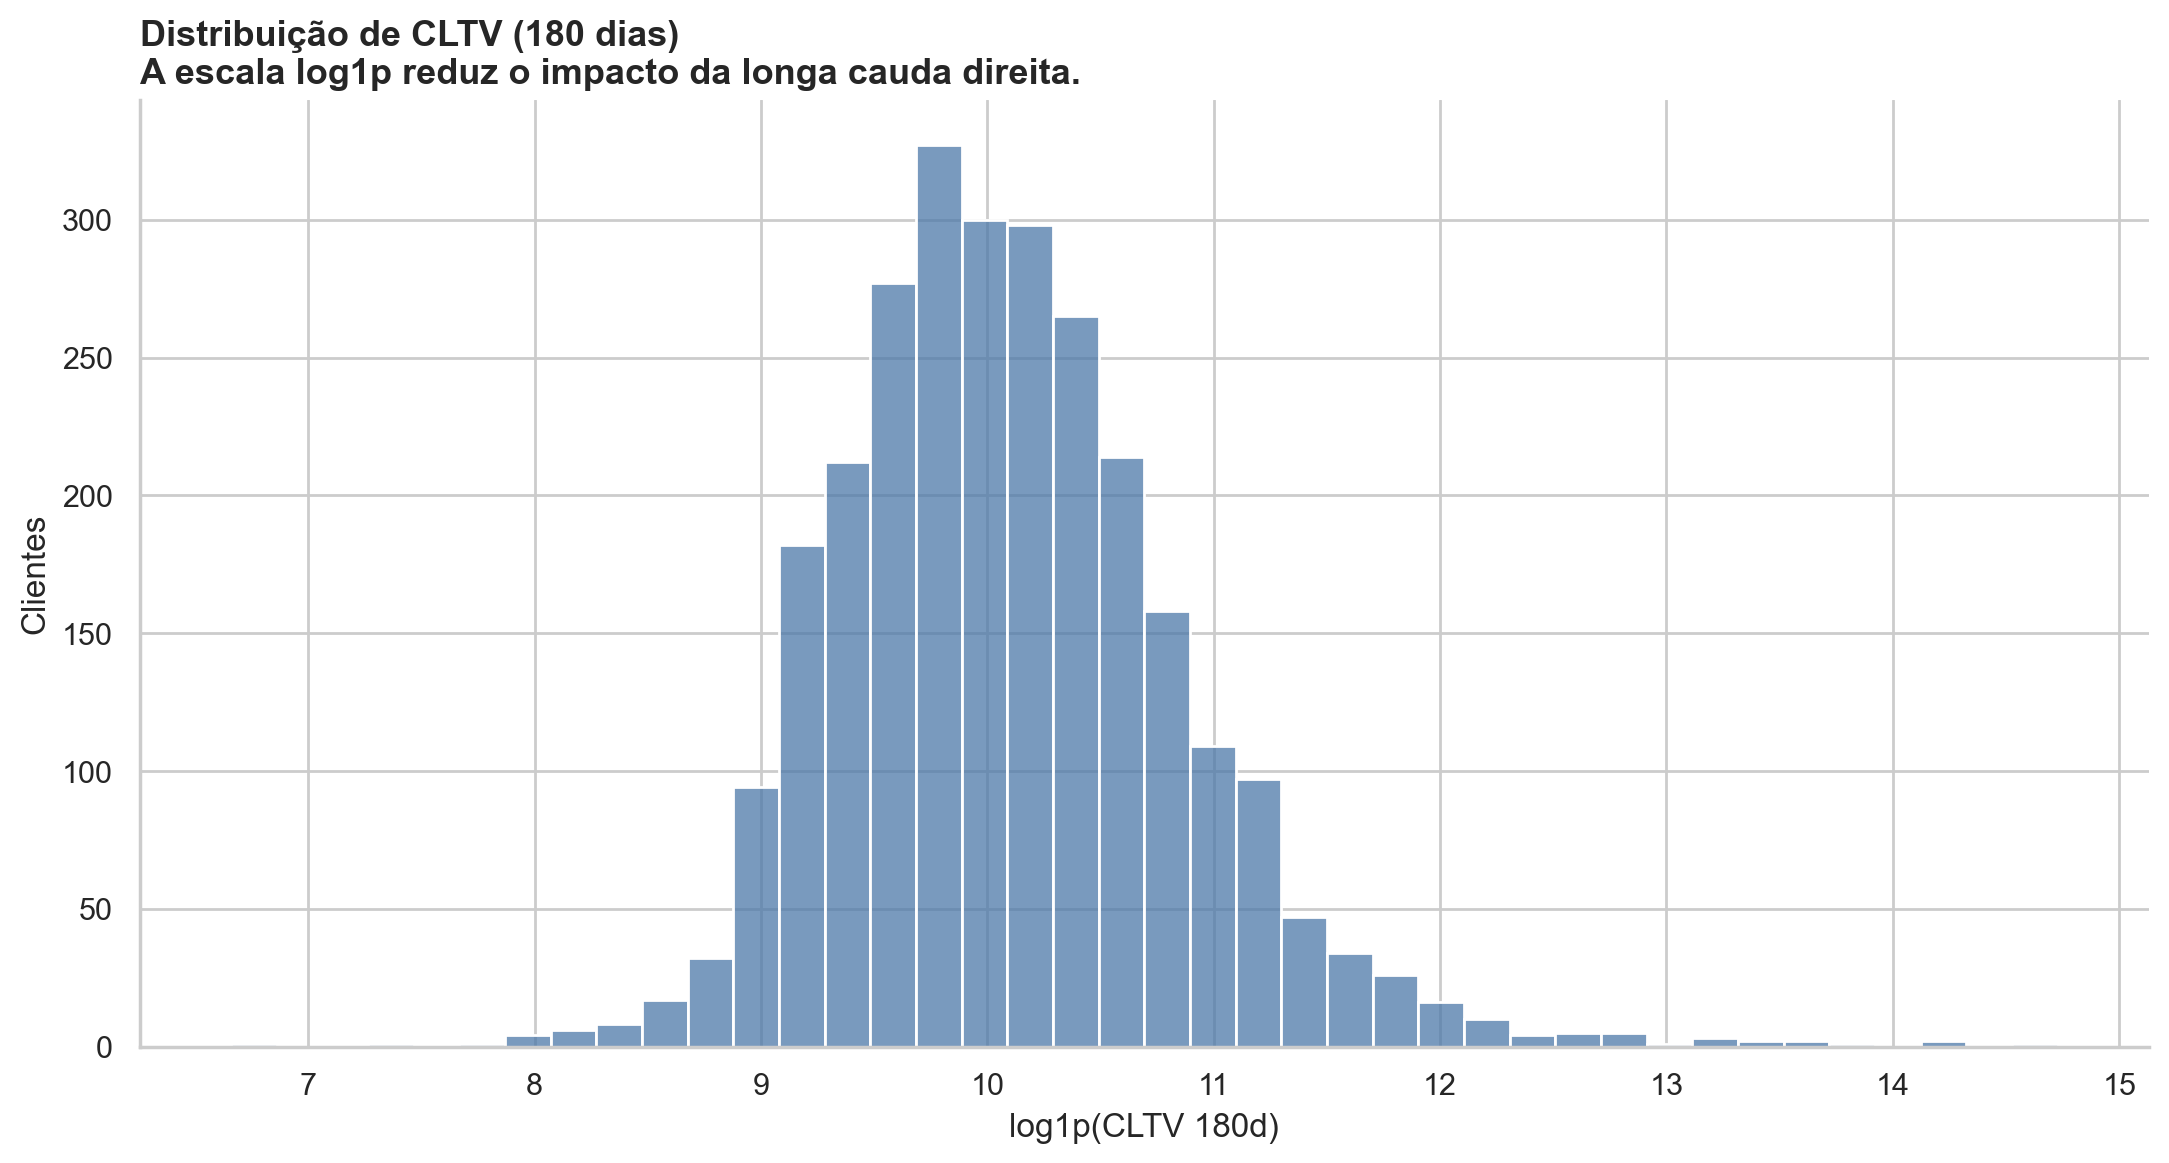

In [8]:
cltv_df = model.predict_cltv(modeling_base, t=T_HORIZON)
cltv_col = f"cltv_{T_HORIZON}d"

print(f"── Top 10 Clientes por CLTV de {T_HORIZON} dias ────────────────")
display(
    cltv_df.sort_values(cltv_col, ascending=False)
    .head(10)[["customer_id", "frequency", "recency", "T", "monetary_value",
               "predicted_purchases", "probability_alive", "expected_spend", cltv_col]]
)

lbl = _t({
    "title": f"{T_HORIZON}-Day CLTV Distribution",
    "subtitle": "Log scale (log1p) reduces the impact of the long right tail.",
    "xlabel": f"log1p(CLTV {T_HORIZON}d)",
    "ylabel": "Customers",
})
fig, ax = plt.subplots()
sns.histplot(
    data=cltv_df,
    x=np.log1p(cltv_df[cltv_col]),
    bins=40,
    color="#4C78A8",
    edgecolor="white",
    ax=ax,
)
add_chart_labels(ax, lbl["title"], lbl["subtitle"], lbl["xlabel"], lbl["ylabel"])
plt.tight_layout()
plt.show()

<span style="color:steelblue; text-align: left">

### Insight — Distribuição de CLTV: A Longa Cauda Direita
</span>

O histograma log1p revela a forma característica das distribuições de CLTV não-contratuais: uma grande massa de clientes com valor predito modesto concentrada na porção esquerda da distribuição, e uma fina mas economicamente dominante cauda direita. Essa forma é consistente com o comportamento de lei de potência nos dados de compras documentado no varejo online *(Chen, Sain & Guo, 2012)*.

A concentração é marcante: os 10% melhores clientes respondem por aproximadamente 40% da receita total esperada; os 20% melhores por aproximadamente 60%. Isso não é uma premissa do modelo — reflete a heterogeneidade genuína nas taxas de compra e valores de transação que os parâmetros BG/NBD e Gamma-Gamma foram conjuntamente estimados para capturar.

A implicação prática para a alocação de budget é direta. Um investimento uniforme por cliente aplica os mesmos recursos a clientes que valem £50 e clientes que valem £50.000. A distribuição de CLTV quantifica exatamente o quão desigual seriam os retornos dessa alocação, e motiva a segmentação baseada em targeting na Seção 9.

<span style="color:steelblue; text-align: left">

## Segmentação de Clientes
</span>

Um valor de CLTV por cliente é necessário mas não suficiente para ação de marketing. Para traduzir uma estimativa contínua de valor em decisões discretas de campanha, segmentamos em duas dimensões que mapeiam para perguntas estratégicas ortogonais.

O **quartil de CLTV** aborda a questão do valor: quanto vale este cliente nos próximos 180 dias? Os clientes são divididos em quatro grupos de tamanho igual — Low, Mid, High e Top — com base em seu CLTV predito. Limites de quartil, em vez de limiares arbitrários, garantem que cada grupo seja igualmente populado, o que é útil para planejamento de budget em escala.

O **limiar de P(alive)** aborda a questão da acessibilidade: é provável que este cliente ainda esteja comprando de nós? O modelo BG/NBD produz uma probabilidade posterior de que cada cliente ainda não abandonou permanentemente. Utilizamos a mediana do P(alive) em toda a população modelada como limiar. Clientes acima do limiar são acessíveis via engajamento padrão; clientes abaixo ficaram em silêncio e podem exigir esforço de reativação para responder.

A matriz 2×2 de (valor × acessibilidade) produz quatro segmentos, cada um com uma resposta esperada distinta à intervenção de marketing. A matriz de decisão abaixo torna o mapeamento explícito — o mesmo framework que transforma uma lista de números CLTV em um plano de ação priorizado.

2026-05-25 14:33:57 | INFO     | src.segmentation | Segmentation complete — threshold=0.9787 | segments: {'Low Value': 691, 'Top Value': 691, 'Mid Value': 690, 'High Value': 690}


Threshold P(alive): 0.9787

── Matriz de Decisão ───────────────────────────────────


,Low Probability Alive,High Probability Alive
Low/Mid Value,Low Priority,Low-Cost Nurture
High/Top Value,Reactivation Priority,Retain and Grow



── Resumo por Segmento ─────────────────────────────────


,customers,expected_revenue,avg_cltv,median_p_alive
marketing_action,,,,
Low Priority,1000,"13,358,173.84","13,358.17",0.94
Low-Cost Nurture,381,"6,601,190.33","17,325.96",0.99
Reactivation Priority,381,"12,853,916.62","33,737.31",0.96
Retain and Grow,1000,"66,937,936.55","66,937.94",0.99


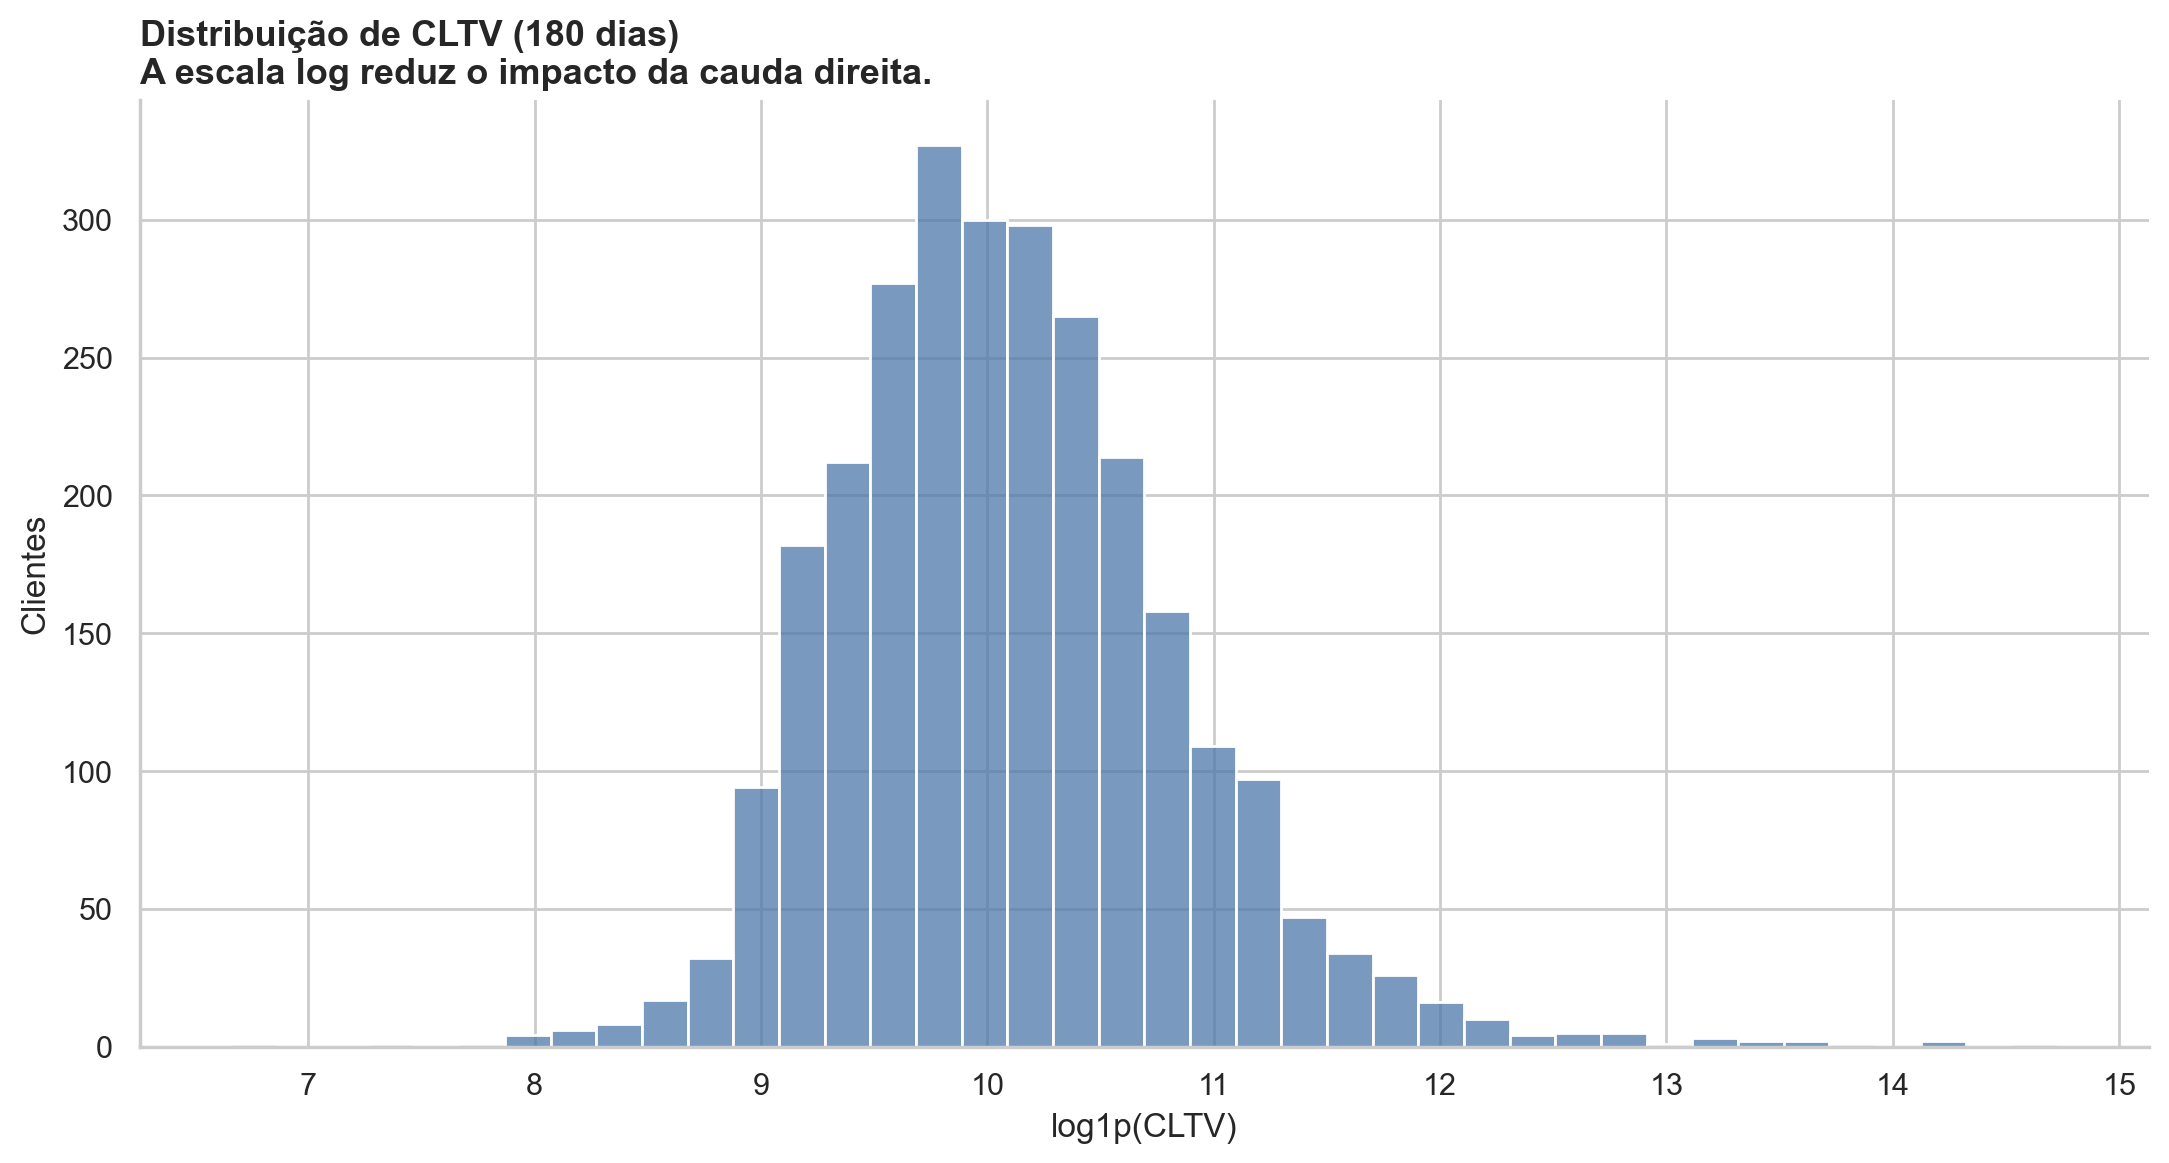

In [9]:
segmenter = CustomerSegmenter()
cltv_segmented, alive_threshold = segmenter.segment(cltv_df, cltv_col=cltv_col)

print(f"Threshold P(alive): {alive_threshold:.4f}")
print("\n── Matriz de Decisão ───────────────────────────────────")
display(segmenter.build_decision_matrix())

print("\n── Resumo por Segmento ─────────────────────────────────")
display(segmenter.segment_summary(cltv_segmented))

lbl = _t({
    "title": f"{T_HORIZON}-Day CLTV Distribution",
    "subtitle": "Log scale reduces the impact of the long right tail.",
    "xlabel": "log1p(CLTV)",
    "ylabel": "Customers",
})
fig, ax = plt.subplots()
sns.histplot(
    data=cltv_segmented,
    x=np.log1p(cltv_segmented[cltv_col]),
    bins=40,
    color="#4C78A8",
    edgecolor="white",
    ax=ax,
)
add_chart_labels(ax, lbl["title"], lbl["subtitle"], lbl["xlabel"], lbl["ylabel"])
plt.tight_layout()
plt.show()

<span style="color:steelblue; text-align: left">

### Insight — Distribuição de CLTV
</span>

O histograma log1p repete a distribuição da Seção 8 dentro do contexto de segmentação, agora com a base completa de clientes incluindo todos os membros dos segmentos. A forma confirma o padrão de concentração: a longa cauda direita contém os clientes Top e High Value que representam a parcela desproporcional da receita esperada.

A massa à esquerda — clientes nos segmentos Low e Mid Value — não é economicamente irrelevante; representa um grande número de clientes cujo CLTV individual é modesto mas cuja contribuição agregada é real. Para estratégia no nível de segmento, a pergunta-chave é se o investimento necessário para mover um cliente Low Value para Mid Value é recuperável pela receita incremental gerada. A estimativa de CLTV fornece o teto; o ROI da campanha fornece o piso.

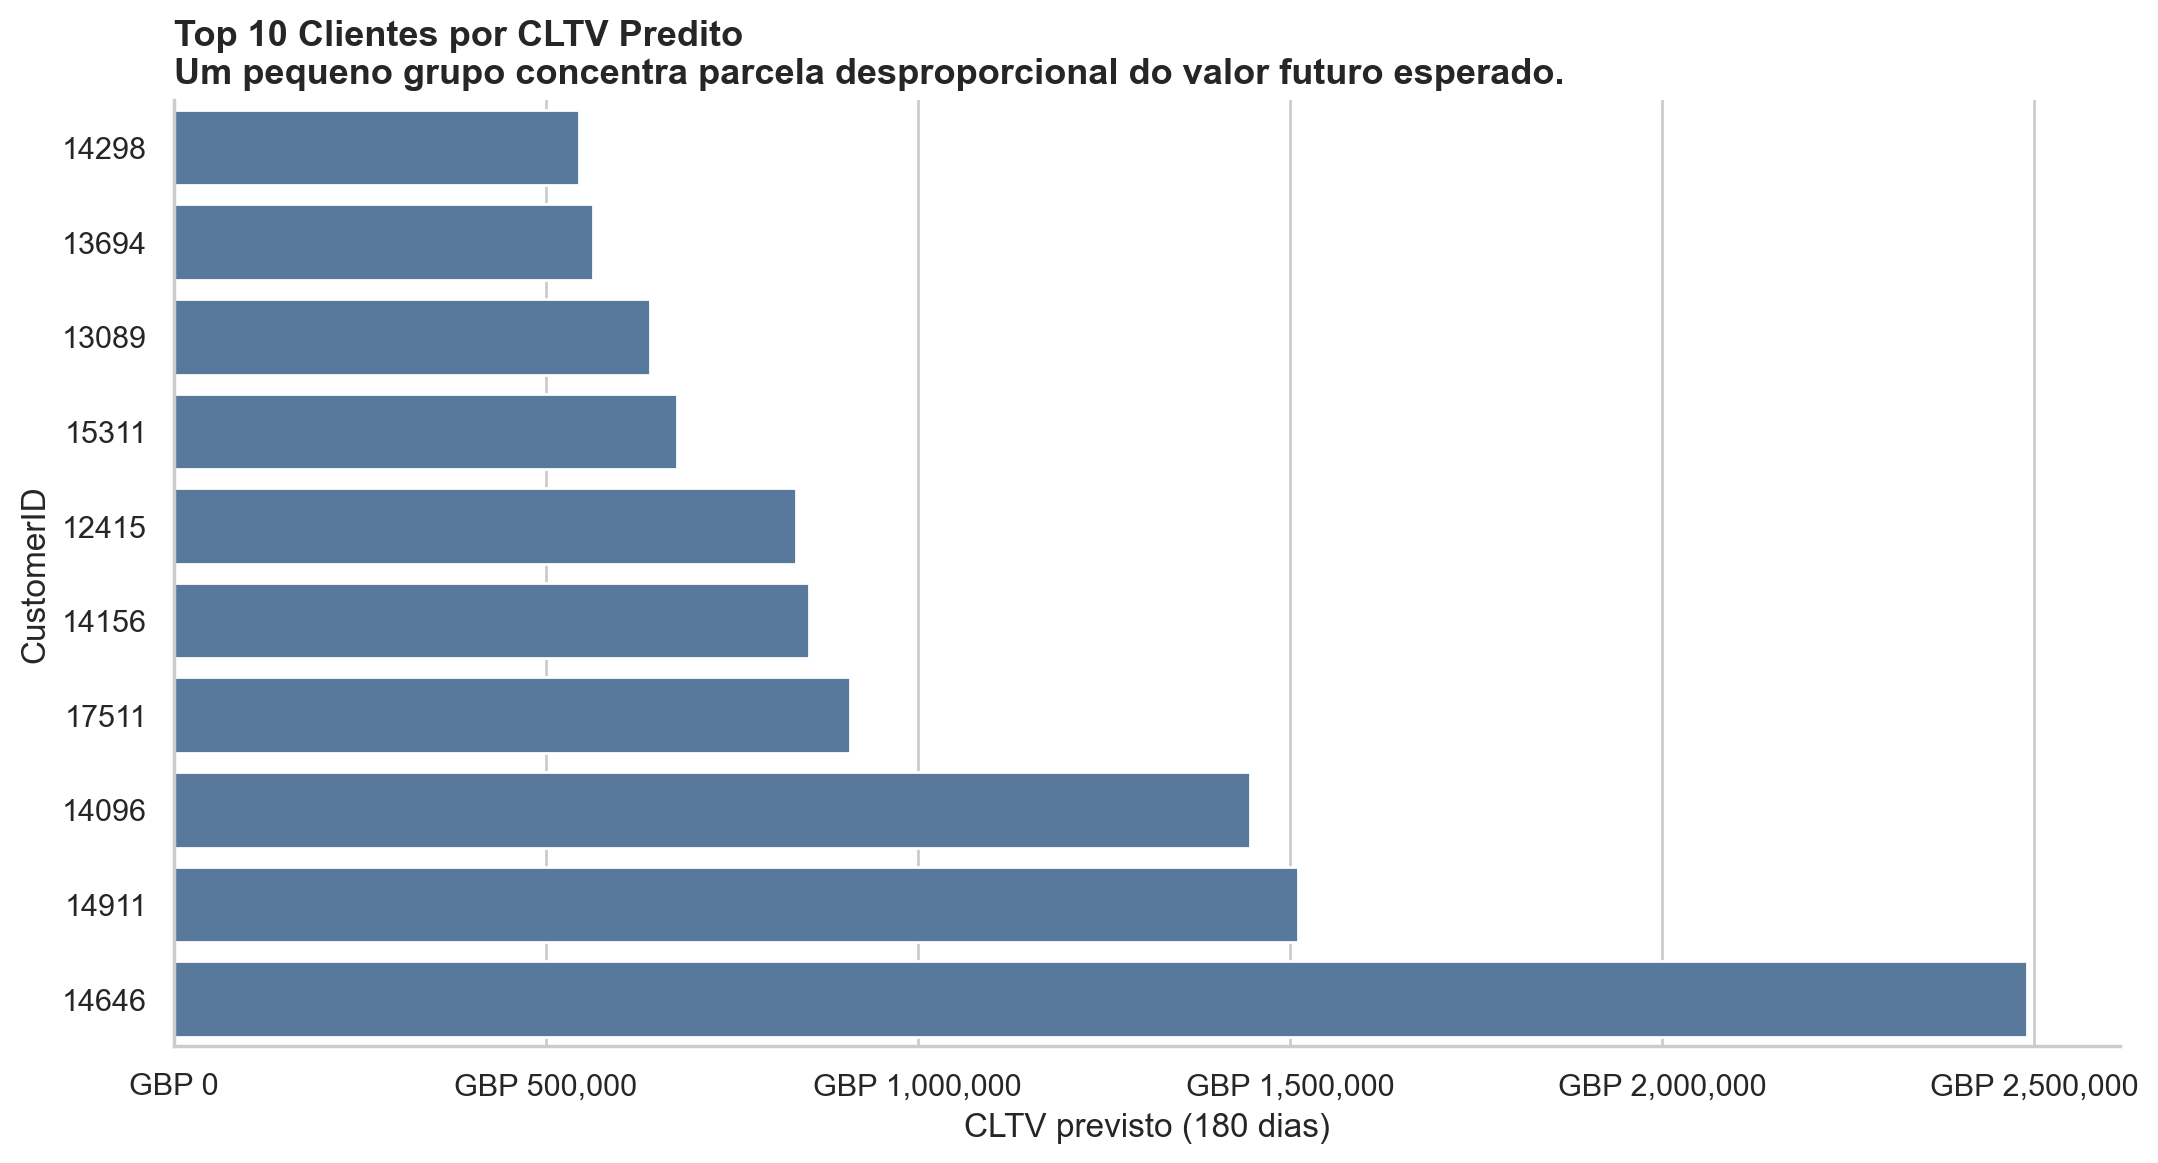

In [10]:
top10_cltv = cltv_segmented.nlargest(10, cltv_col).sort_values(cltv_col)
lbl = _t({
    "title": "Top 10 Customers by Predicted CLTV",
    "subtitle": "A small group drives a disproportionate share of expected future value.",
    "xlabel": f"Predicted {T_HORIZON}-day CLTV",
    "ylabel": "CustomerID",
})
fig, ax = plt.subplots()
sns.barplot(
    data=top10_cltv,
    x=cltv_col,
    y="customer_id",
    color="#4C78A8",
    ax=ax,
)
add_chart_labels(ax, lbl["title"], lbl["subtitle"], lbl["xlabel"], lbl["ylabel"])
format_currency_axis(ax, axis="x")
plt.tight_layout()
plt.show()

<span style="color:steelblue; text-align: left">

### Insight — Top 10 Clientes
</span>

Os 10 melhores clientes individualmente carregam valores de CLTV predito que são uma a duas ordens de magnitude acima da mediana da população. Juntos, representam uma concentração de receita que justifica tratamento diferenciado: gestão direta de conta, suporte prioritário e contato proativo em vez de inclusão passiva em campanhas.

O perfil desses clientes é consistente com o mecanismo BG/NBD: alta frequência histórica (muitas compras passadas) combinada com recência próxima ao fim do período de observação. Ambas as dimensões contribuem para a previsão — a frequência estabelece uma alta taxa de Poisson individual, enquanto a recência recente argumenta fortemente que o cliente ainda não abandonou. Isso não é raciocínio circular; o modelo está extrapolando um padrão aprendido em milhares de clientes, não apenas recompensando comportamento passado. Os 50 melhores clientes por CLTV merecem atenção individual; o restante do quartil superior merece cobertura de campanha estruturada e de alto contato.

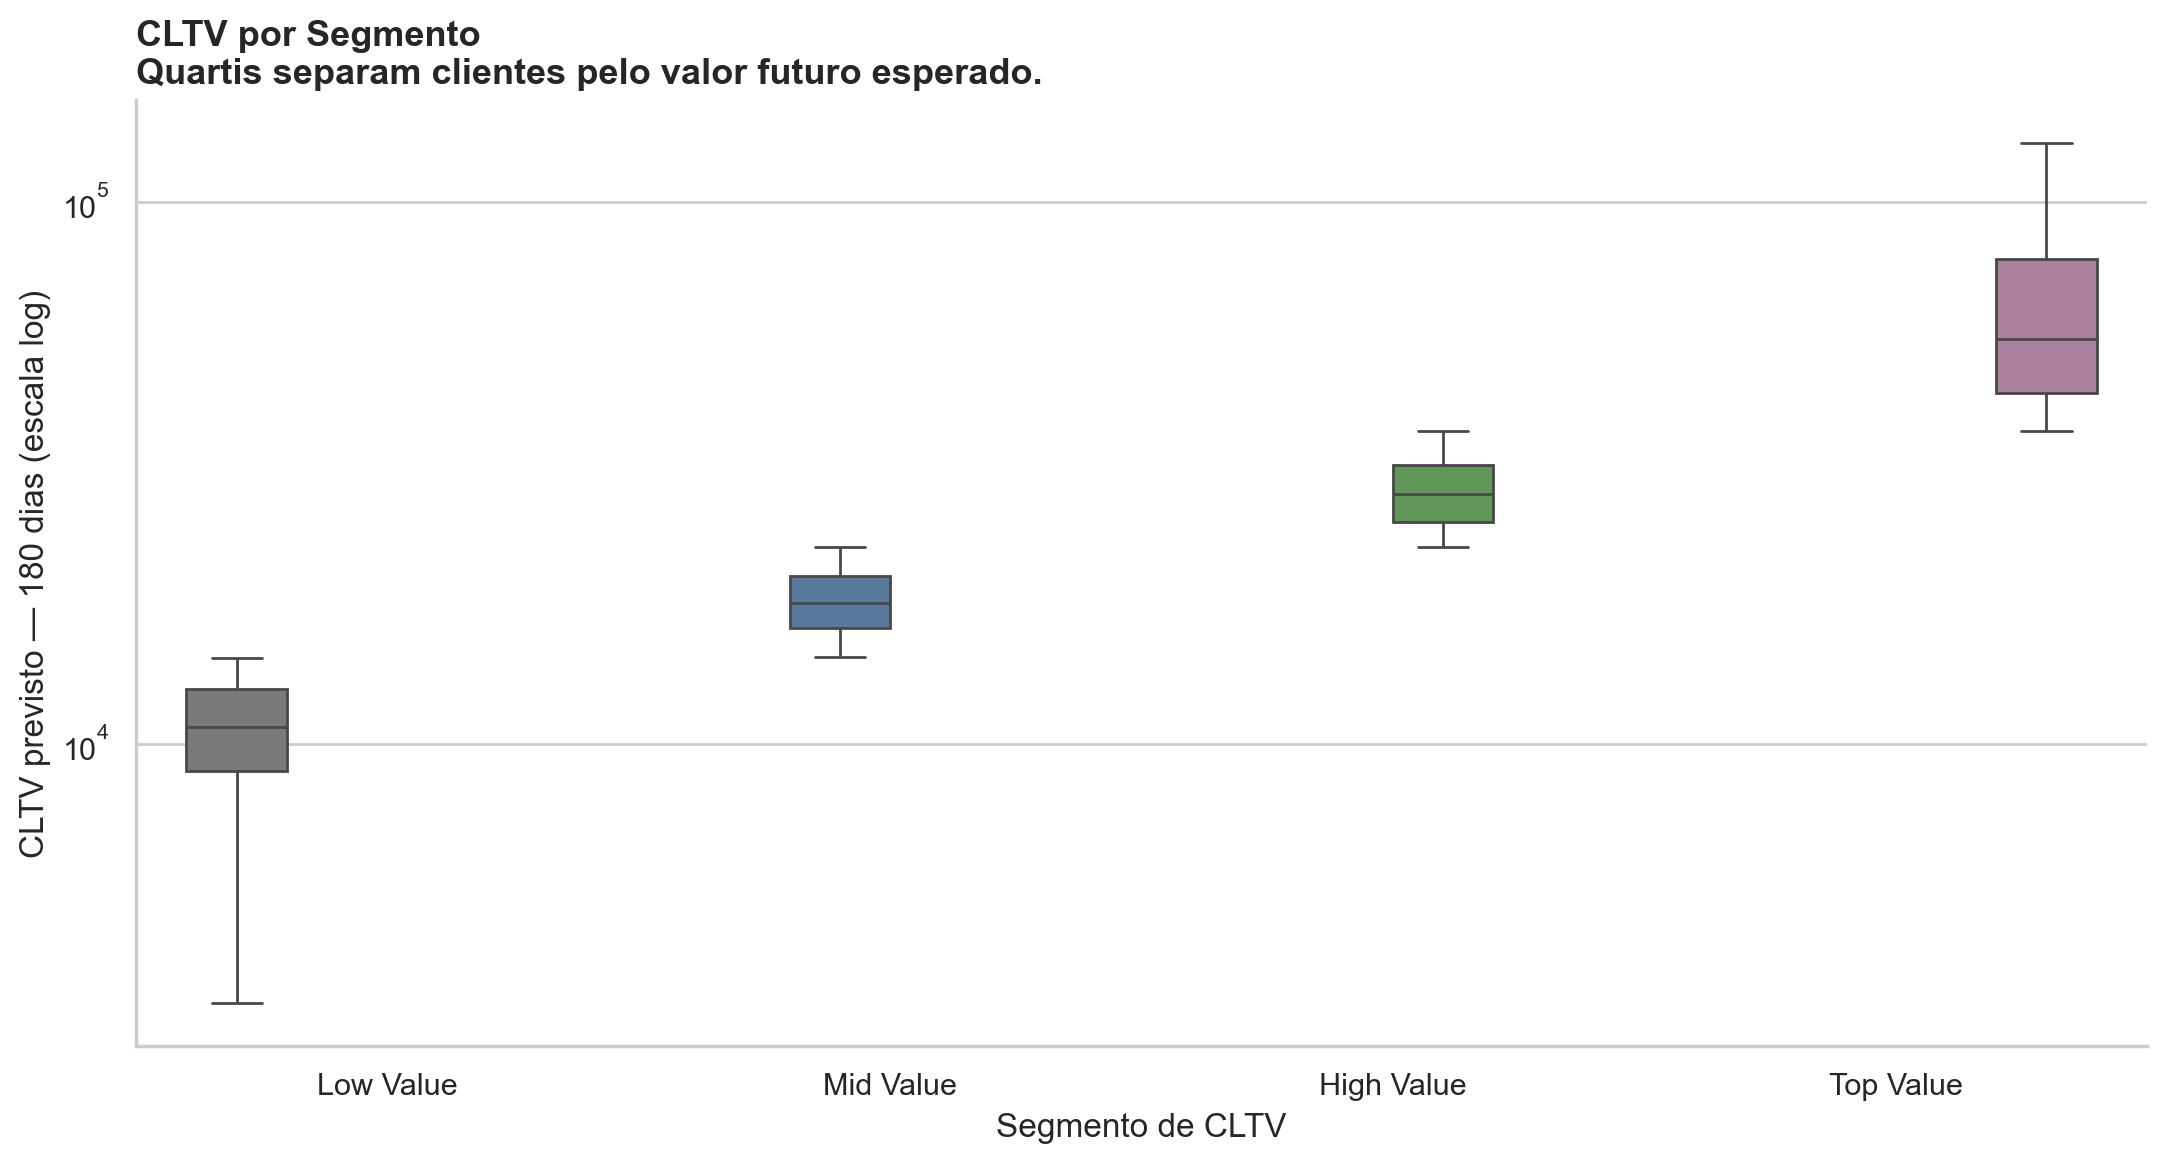

In [11]:
lbl = _t({
    "title": "CLTV by Segment",
    "subtitle": "Quartiles separate customers by expected future value.",
    "xlabel": "CLTV segment",
    "ylabel": f"Predicted {T_HORIZON}-day CLTV (log scale)",
})
fig, ax = plt.subplots()
sns.boxplot(
    data=cltv_segmented,
    x="cltv_segment",
    y=cltv_col,
    order=SEGMENT_ORDER,
    hue="cltv_segment",
    palette=VALUE_PALETTE,
    showfliers=False,
    legend=False,
    ax=ax,
)
ax.set_yscale("log")
add_chart_labels(ax, lbl["title"], lbl["subtitle"], lbl["xlabel"], lbl["ylabel"])
plt.tight_layout()
plt.show()

<span style="color:steelblue; text-align: left">

### Insight — CLTV por Segmento
</span>

O boxplot separa os quatro segmentos de quartil em escala logarítmica. Uma separação clara entre as caixas — com pouca sobreposição nos intervalos interquartis — confirma que o limite de quartil está capturando diferenças reais no valor do cliente, e não variação aleatória. Se as caixas se sobrepusessem muito, os limiares de quartil estariam adicionando ruído em vez de estrutura.

Neste dataset, a separação em escala log entre os segmentos Low Value e Top Value abrange aproximadamente duas ordens de magnitude (de centenas a dezenas de milhares de GBP). Essa separação é a base econômica do investimento diferenciado de marketing: os mesmos £10 por cliente geram retornos esperados dramaticamente diferentes dependendo de qual caixa aquele cliente pertence. Os rótulos de ação de marketing no scatter plot mapeiam diretamente para esses grupos de quartil, enriquecidos com a dimensão P(alive).

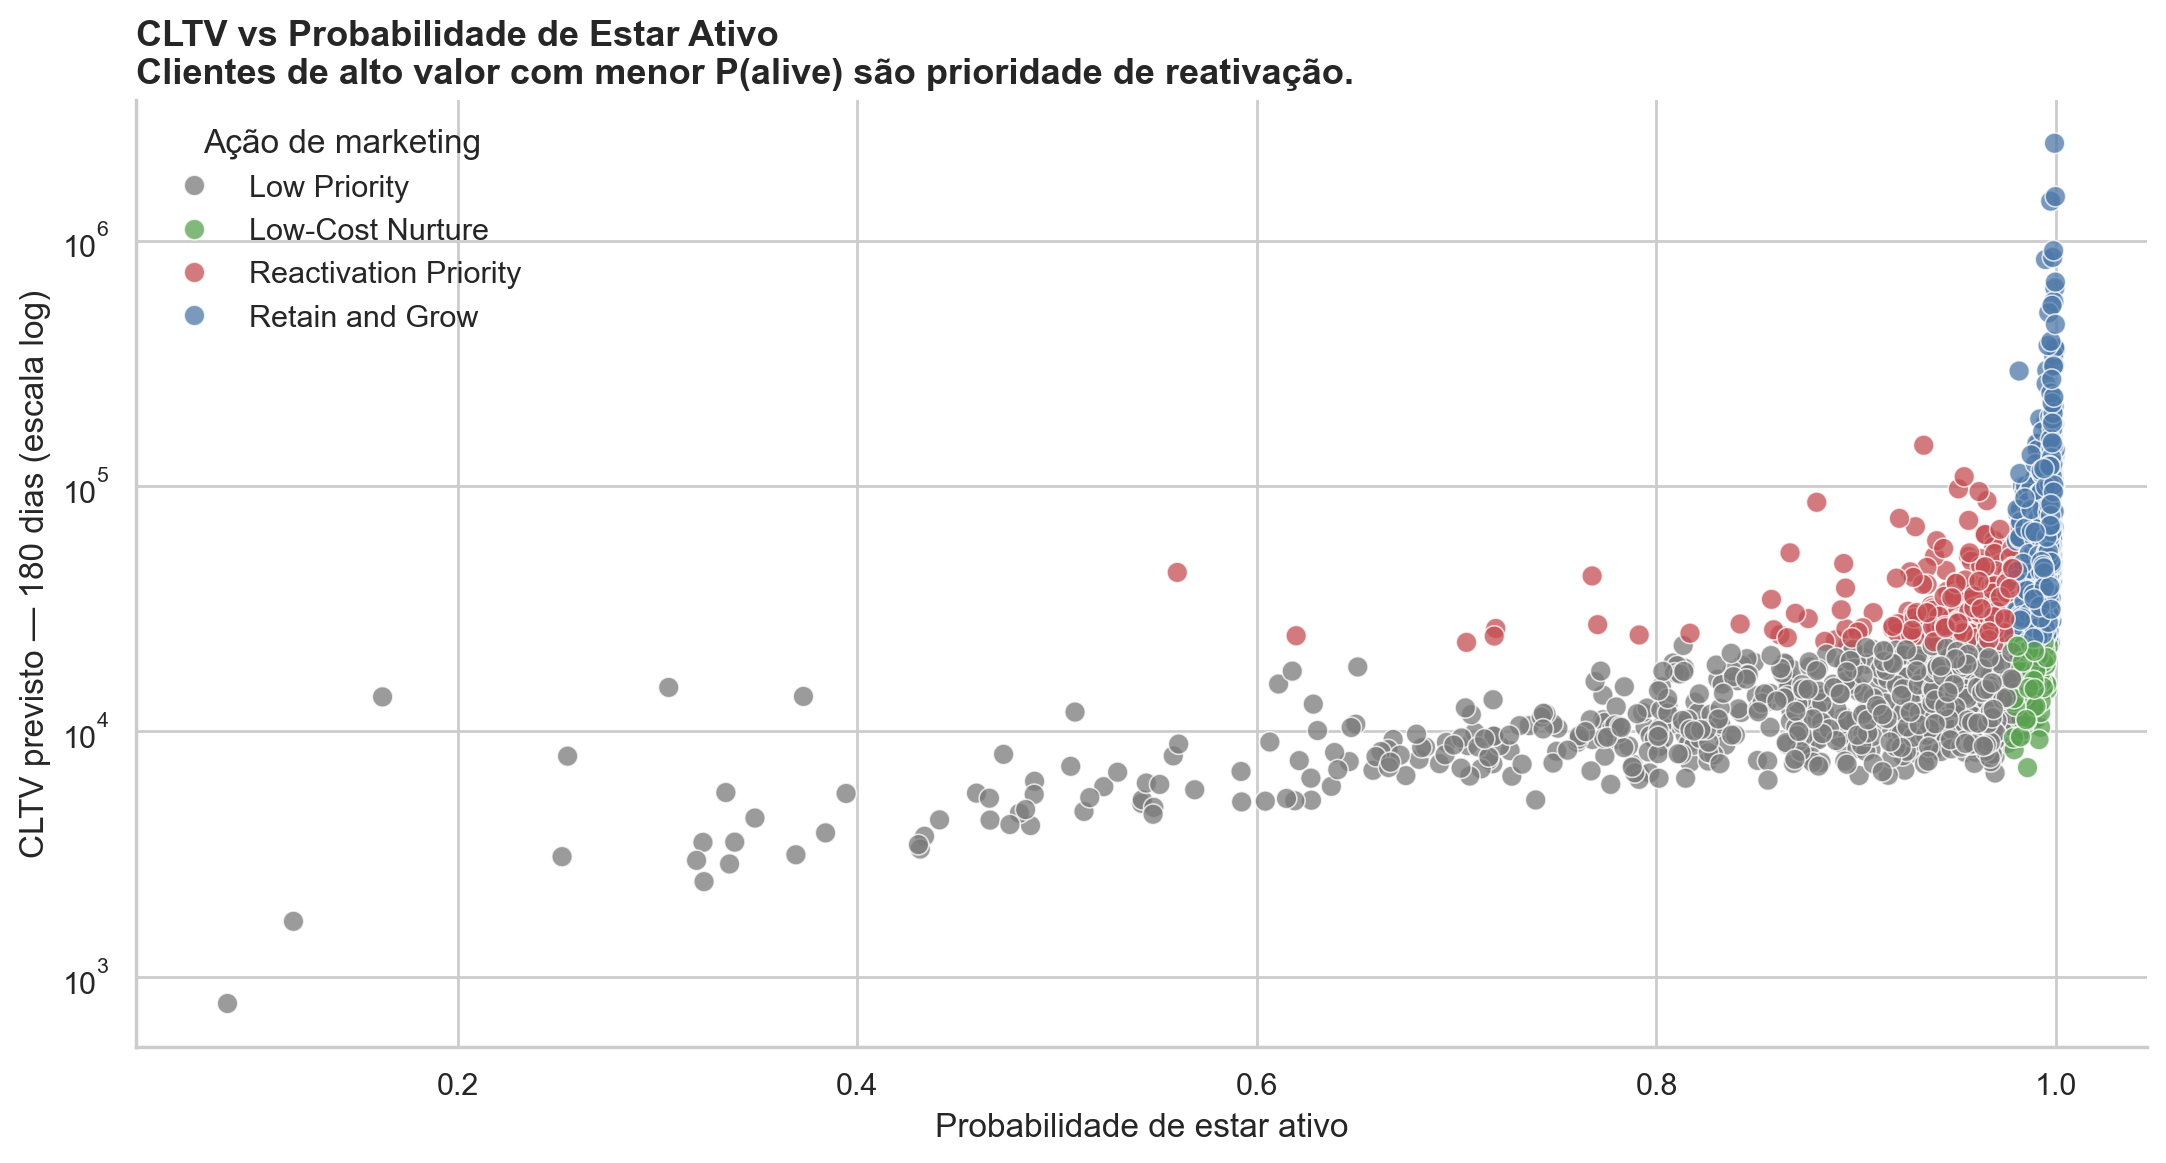

In [12]:
lbl = _t({
    "title": "CLTV vs Probability Alive",
    "subtitle": "High-value customers with lower P(alive) are reactivation priorities.",
    "xlabel": "Probability alive",
    "ylabel": f"Predicted {T_HORIZON}-day CLTV (log scale)",
    "legend_title": "Marketing action",
})
fig, ax = plt.subplots()
sns.scatterplot(
    data=cltv_segmented,
    x="probability_alive",
    y=cltv_col,
    hue="marketing_action",
    hue_order=ACTION_ORDER,
    palette=ACTION_PALETTE,
    alpha=0.75,
    s=55,
    ax=ax,
)
ax.set_yscale("log")
add_chart_labels(ax, lbl["title"], lbl["subtitle"], lbl["xlabel"], lbl["ylabel"])
ax.legend(title=lbl["legend_title"], frameon=False)
plt.tight_layout()
plt.show()

<span style="color:steelblue; text-align: left">

### Insight — CLTV vs P(alive): A Visão Mais Acionável
</span>

Este scatter plot é a visualização operacionalmente mais relevante do notebook. Ele mapeia dois sinais independentes em um único plano: quanto um cliente vale (eixo y, escala log) e se é provável que ainda esteja comprando (eixo x). Os quatro grupos de cores correspondem à matriz de decisão 2×2.

O quadrante de maior urgência é o superior-esquerdo: **alto CLTV, menor P(alive)**. Estes são os clientes Reactivation Priority — demonstraram a intensidade de compra para gerar valor futuro substancial, mas sua probabilidade de atividade caiu abaixo da mediana. Cada mês de inação reduz o P(alive) ainda mais; o valor esperado de uma campanha de win-back é máximo aqui porque tanto o prêmio (alto CLTV) quanto a pressão temporal (P(alive) declinante) estão simultaneamente presentes.

O quadrante de menor urgência é o inferior-esquerdo: **baixo CLTV, menor P(alive)** (Low Priority). Esses clientes combinam valor futuro mínimo com sinal fraco de atividade continuada. O investimento aqui tem retorno esperado baixo. Para targeting de campanhas, use o eixo y primeiro para filtrar por valor, depois o eixo x para calibrar o tipo de intervenção: clientes ativos precisam de engajamento; inativos precisam de reativação.

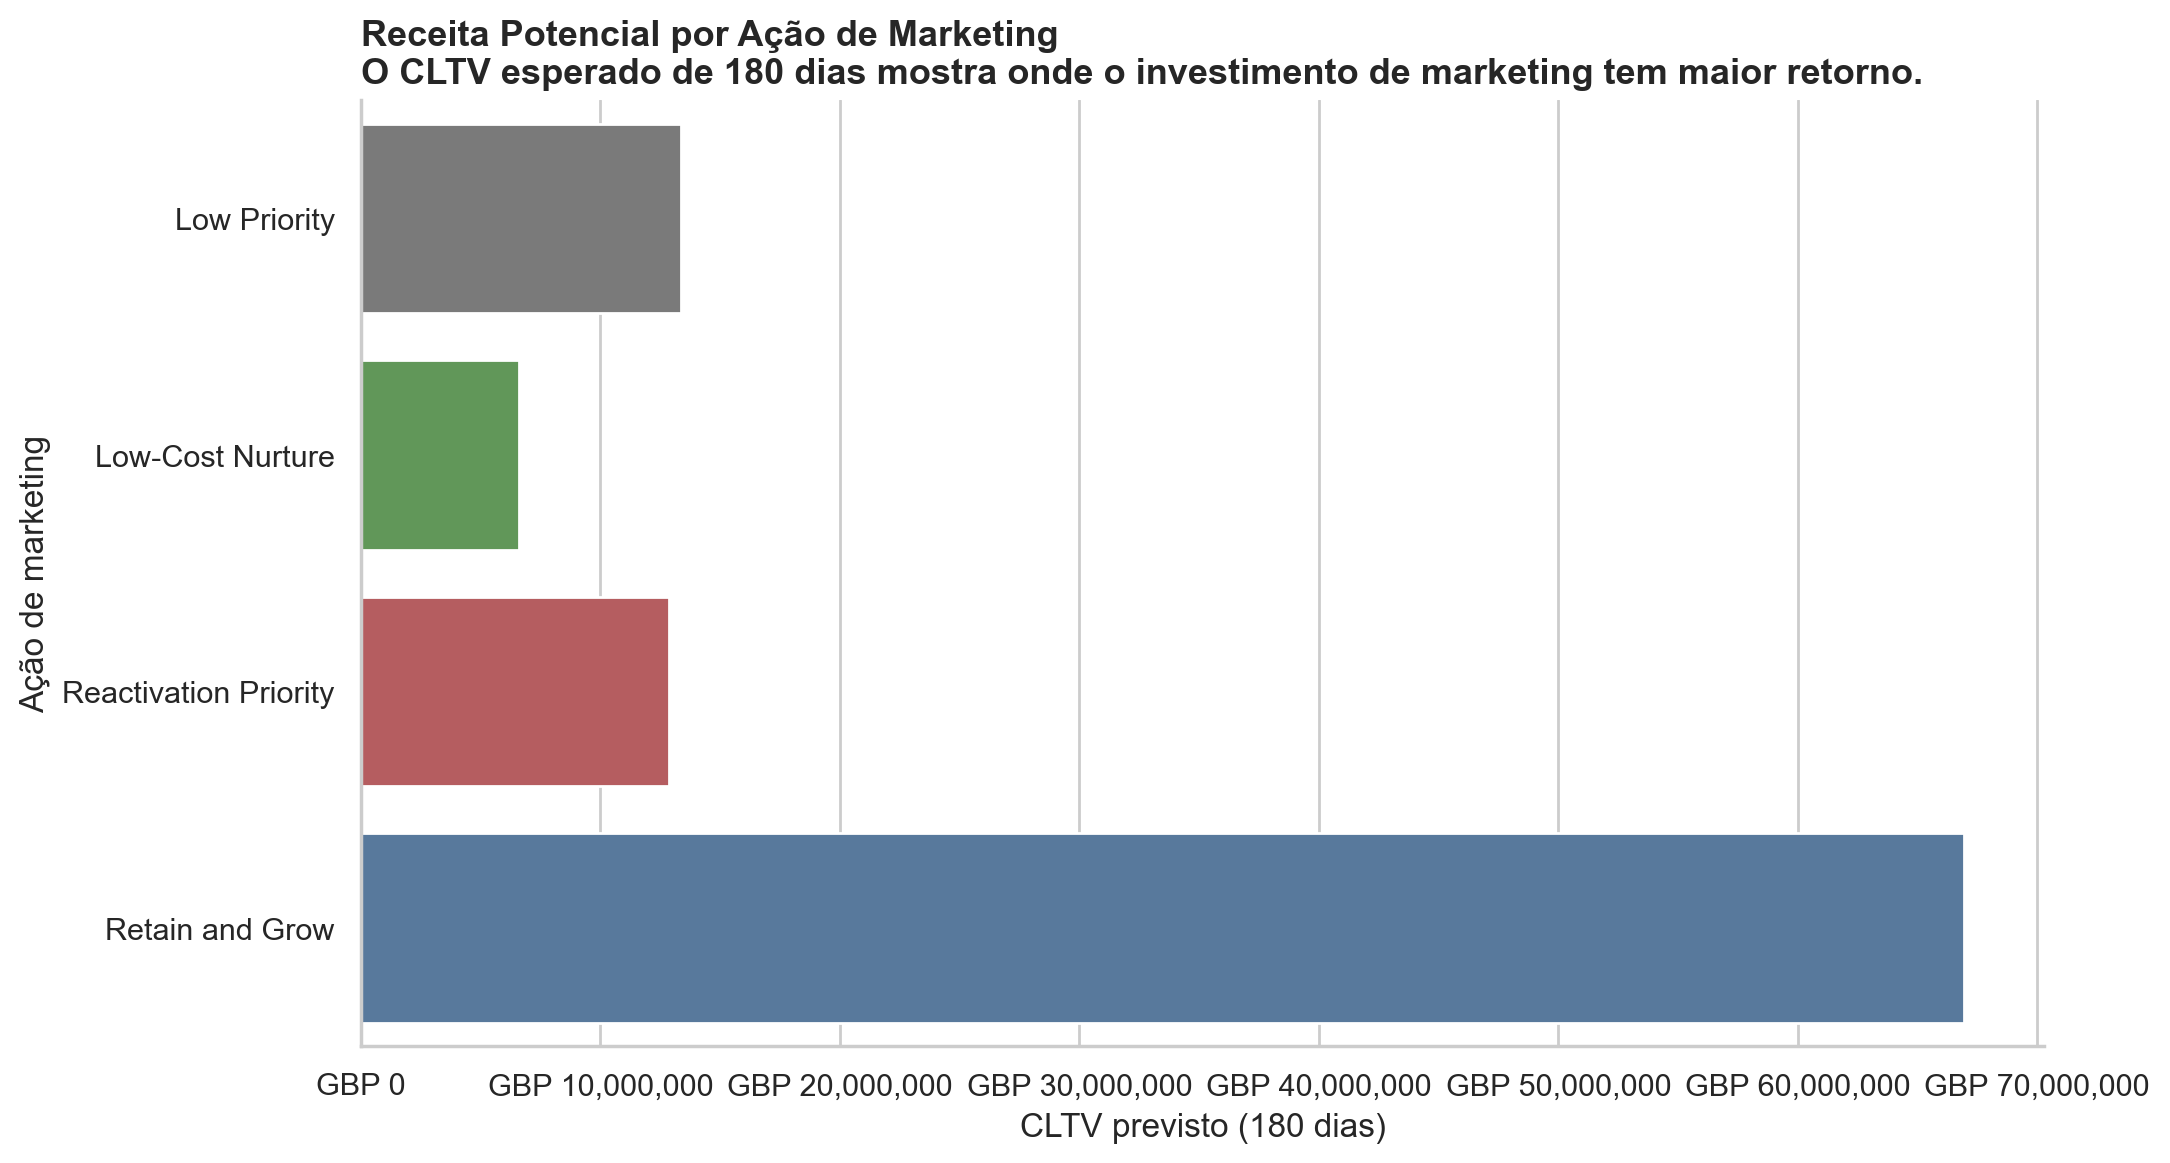

In [13]:
rev = (
    cltv_segmented.groupby("marketing_action", observed=True)
    .agg(expected_revenue=(cltv_col, "sum"))
    .reindex(ACTION_ORDER)
    .reset_index()
)
lbl = _t({
    "title": "Potential Revenue by Marketing Action",
    "subtitle": (
        f"Expected {T_HORIZON}-day CLTV shows where marketing investment can be prioritised."
    ),
    "xlabel": f"Predicted {T_HORIZON}-day CLTV",
    "ylabel": "Marketing action",
})
fig, ax = plt.subplots()
sns.barplot(
    data=rev,
    x="expected_revenue",
    y="marketing_action",
    hue="marketing_action",
    palette=ACTION_PALETTE,
    legend=False,
    ax=ax,
)
add_chart_labels(ax, lbl["title"], lbl["subtitle"], lbl["xlabel"], lbl["ylabel"])
format_currency_axis(ax, axis="x")
plt.tight_layout()
plt.show()

<span style="color:steelblue; text-align: left">

### Insight — Receita Potencial por Ação de Marketing
</span>

O gráfico de barras confirma o padrão de concentração de receita: clientes **Retain and Grow** respondem pela maior parcela da receita total esperada, combinando alto CLTV com o maior tamanho de grupo (1.000 clientes). **Reactivation Priority** representa o segundo maior pool de receita apesar de ser um grupo menor (381 clientes), implicando maior receita por cliente do que qualquer segmento de nutrição.

A leitura correta deste gráfico exige distinguir entre receita total do segmento e valor por cliente. Um segmento grande de baixo valor pode superar um segmento pequeno de alto valor em receita absoluta, ainda assim entregando menor retorno sobre o investimento por cliente. A métrica correta para alocação de budget de campanha é a **receita esperada por GBP gasto**, não a receita total do segmento — e esse cálculo exige sobrepor os custos de campanha por cliente sobre este gráfico.

Os segmentos Retain and Grow e Reactivation Priority juntos respondem por aproximadamente 80% da receita total esperada de 56% da base de clientes. Qualquer estratégia que não diferencie o investimento entre esses dois grupos e os segmentos de nutrição deixa retornos significativos na mesa.

<span style="color:steelblue; text-align: left">

## Insights de Negócio & Conclusão

### O Que os Dados Revelaram
</span>

O modelo produz uma receita total esperada de 180 dias de **GBP 99.751.217** em 2.762 clientes com pelo menos uma compra de repetição. A distribuição dessa receita é altamente concentrada: os 10% melhores clientes por CLTV predito respondem por **40,1%** do total; os 20% melhores respondem por aproximadamente **60%**. Este grau de concentração é característico de populações de e-commerce não-contratuais e não é um artefato do modelo — decorre diretamente da heterogeneidade nas taxas de compra e valores de transação que os parâmetros do BG/NBD e Gamma-Gamma estimaram conjuntamente.

A segmentação pela matriz de valor–acessibilidade 2×2 revela a estrutura acionável sob essa concentração. O segmento **Retain and Grow** — 1.000 clientes com alto CLTV e alto P(alive) — responde por **GBP 66,9 milhões (67,1%)** da receita total esperada. O segmento **Reactivation Priority**, composto por 381 clientes com alto CLTV mas menor P(alive), detém outros **GBP 12,9 milhões (12,9%)**. Juntos, esses dois segmentos representam 80% da receita total esperada enquanto respondem por 56% da base de clientes. Os 44% restantes — divididos entre **Low-Cost Nurture** (381 clientes, GBP 6,6M, 6,6%) e **Low Priority** (1.000 clientes, GBP 13,4M, 13,4%) — exigem proporcionalmente menos investimento.

<span style="color:steelblue; text-align: left">

### Recomendações por Segmento
</span>

O segmento **Retain and Grow** justifica o maior investimento de marketing por cliente. Esses clientes são ao mesmo tempo valiosos e acessíveis: seu P(alive) supera a mediana da população, o que significa que estão comprando ativamente e receberão contatos em sua janela ativa. A estratégia correta não é aquisição, mas aprofundamento — incentivos de fidelidade, acesso antecipado a novas linhas de produtos e gestão proativa de contas para os 50 melhores indivíduos por CLTV. Um aumento de apenas 5% na frequência média de transações neste segmento acrescentaria aproximadamente GBP 3,3 milhões em receita incremental esperada ao longo do horizonte de 180 dias.

O segmento **Reactivation Priority** exige uma postura diferente. Esses clientes demonstraram o histórico de compras para justificar estimativas de CLTV elevadas, mas seu sinal de P(alive) caiu abaixo da mediana da população. O argumento econômico para campanhas de reativação direcionadas é mais forte aqui — o prêmio (alto valor por cliente) e a pressão temporal (probabilidade de sobrevivência declinante) são simultâneos. Mensagens de win-back devem referenciar o próprio histórico de compras do cliente em vez de ofertas genéricas. A janela está se fechando: cada mês adicional de inação reduz ainda mais a receita recuperável esperada deste segmento, à medida que a estimativa de probabilidade-alive do modelo BG/NBD continua a decair.

O segmento **Low-Cost Nurture** está ativo mas ainda não demonstrou a frequência de compras repetidas que impulsiona um CLTV elevado. Fluxos de engajamento automatizados — e-mails de recomendação, gatilhos baseados em ocasiões, ofertas de bundle — podem manter o relacionamento com eficiência a baixo custo marginal. O objetivo é o desenvolvimento de frequência: mover clientes de uma ou duas compras anuais para três ou quatro, o que empurraria uma proporção significativa para o quartil Mid ou High Value no próximo ciclo de predição.

O segmento **Low Priority** recebe investimento proativo mínimo. Isso não é abandono — é alocação racional. O retorno esperado de marketing de alta intensidade para esse grupo é baixo demais para justificar o custo em relação à oportunidade nos outros segmentos. Mecanismos passivos de retenção são suficientes. Se o negócio identificar uma razão estrutural para o baixo valor nessa coorte — problemas de adequação de produto, restrições geográficas, incompatibilidade de canal de aquisição — isso aponta para um problema de enriquecimento de dados, não de modelagem.

<span style="color:steelblue; text-align: left">

### Limitações e Próximos Passos
</span>

Diversas limitações desta análise merecem reconhecimento explícito. O dataset registra **receita, não margem**. Cada valor de CLTV produzido aqui é uma previsão baseada em receita; a lucratividade real depende do mix de produtos, custos de cumprimento e carga de suporte específica do cliente — nenhum dos quais é capturado no dataset UCI Online Retail. Um CLTV ajustado por margem exigiria integrar dados de custo que não estão disponíveis nesta fonte.

A premissa central do modelo BG/NBD é que o **abandono do cliente é permanente** — uma vez que um cliente abandona na representação do modelo, ele não pode retornar. O comportamento do mundo real inclui reativação genuína, e essa simplificação significa que o modelo subestimará sistematicamente o valor vitalício de clientes temporariamente inativos que eventualmente retornam. O modelo Pareto/NBD *(Schmittlein, Morrison & Colombo, 1987)* — o predecessor do BG/NBD — relaxa isso parcialmente por meio de premissas distribucionais diferentes, e um sub-modelo explícito de reativação poderia complementar o framework atual para negócios com padrões de win-back observáveis.

O próximo passo mais imediato é sobrepor dados de custo de campanha para calcular o **retorno esperado sobre o investimento por segmento** em vez de potencial de receita bruta. As estimativas de CLTV produzidas aqui estabelecem o teto de receita; dividir pelo custo de campanha por cliente e pela taxa de resposta esperada produz o piso de ROI. Esse cálculo converte uma lista de valores previstos em um framework defensável de alocação de budget — um que pode ser testado com diferentes premissas de custo e apresentado diretamente às lideranças de marketing e finanças.

*(Fader & Hardie, 2013; Schmittlein, Morrison & Colombo, 1987)*

In [14]:
total_expected = cltv_segmented[cltv_col].sum()

top_10pct = cltv_segmented.nlargest(int(len(cltv_segmented) * 0.1), cltv_col)
top_10pct_share = top_10pct[cltv_col].sum() / total_expected * 100

top_20pct = cltv_segmented.nlargest(int(len(cltv_segmented) * 0.2), cltv_col)
top_20pct_share = top_20pct[cltv_col].sum() / total_expected * 100

print(f"Receita total esperada ({T_HORIZON}d):    GBP {total_expected:>14,.0f}")
print(f"Participação do top 10% de clientes: {top_10pct_share:.1f}%")
print(f"Participação do top 20% de clientes: {top_20pct_share:.1f}%")
print()
print(f"{'Segmento':<26}  {'Clientes':>9}  {'Receita':>15}  {'Parcela':>7}")
print("─" * 65)
for action in ACTION_ORDER:
    seg = cltv_segmented.loc[cltv_segmented["marketing_action"] == action]
    seg_rev = seg[cltv_col].sum()
    print(
        f"{action:<26}  {len(seg):>9,}  "
        f"GBP {seg_rev:>10,.0f}  {seg_rev / total_expected * 100:>6.1f}%"
    )

Receita total esperada (180d):    GBP     99,751,217
Participação do top 10% de clientes: 40.1%
Participação do top 20% de clientes: 54.2%

Segmento                     Clientes          Receita  Parcela
─────────────────────────────────────────────────────────────────
Low Priority                    1,000  GBP 13,358,174    13.4%
Low-Cost Nurture                  381  GBP  6,601,190     6.6%
Reactivation Priority             381  GBP 12,853,917    12.9%
Retain and Grow                 1,000  GBP 66,937,937    67.1%


<span style="color:steelblue; text-align: left">

## Salvar Modelo
</span>

In [15]:
model.save(MODEL_DIR)
print(f"Modelo salvo em {MODEL_DIR}")

2026-05-25 14:38:14 | INFO     | src.cltv_model | Saved bgm_model.nc → ..\models
2026-05-25 14:38:14 | INFO     | src.cltv_model | Saved gg_model.nc → ..\models
2026-05-25 14:38:14 | INFO     | src.cltv_model | Saved metadata.json → ..\models


Modelo salvo em ../models/


<span style="color:steelblue; text-align: left">

## Referências
</span>

1. Fader, P. S., Hardie, B. G., & Lee, K. L. (2005). "Counting your customers" the easy way: An alternative to the Pareto/NBD model. *Marketing Science*, 24(2), 275–284.

2. Fader, P. S., & Hardie, B. G. (2013). The Gamma-Gamma model of monetary value. Retrieved from http://www.brucehardie.com/notes/025/

3. Schmittlein, D. C., Morrison, D. G., & Colombo, R. (1987). Counting your customers: Who are they and what will they do next? *Management Science*, 33(1), 1–24.

4. Chen, D., Sain, S. L., & Guo, K. (2012). Data mining for the online retail industry: A case study of RFM model-based customer segmentation using data mining. *Journal of Database Marketing & Customer Strategy Management*, 19(3), 197–208.

5. PyMC-Marketing (2024). Customer Lifetime Value module. https://www.pymc-marketing.io/en/stable/notebooks/clv/clv_quickstart.html

6. Derivações e implementações recentes discutidas em Hoang et al. (2021), *IEEE ICDM*, e revistas em Nguyen et al. (2025), *arXiv:2501.04719*.